In [74]:
!pip install ydata-profiling
!pip install markupsafe==2.0.1

In [75]:
# Imports

from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from ydata_profiling import ProfileReport
import missingno as msno
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neighbors import KNeighborsClassifier
from lightgbm import LGBMRegressor
from lightgbm import LGBMClassifier
from xgboost import XGBRegressor
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import joblib
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, median_absolute_error
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
warnings.filterwarnings('ignore')

#Introducción

Al predecir la probabilidad de rotación de empleados, las organizaciones y compañías pueden tomar decisiones informadas para mejorar la retención de talento y reducir los costos asociados con la contratación y capacitación de nuevos empleados.

El análisis y posterior modelo de predicción que se va a realizar en este proyecto puede identificar a los empleados en riesgo de dejar la empresa, lo que permite a los gerentes implementar medidas preventivas, como promociones, aumentos salariales, programas de desarrollo profesional o intervenciones de bienestar laboral. Además, también puede ayudar a identificar patrones o factores comunes entre los empleados que dejan la compañía, lo que brinda a la empresa una oportunidad para ajustar su cultura organizacional, beneficios o condiciones de trabajo.

A lo largo de este proyecto se van a realizar primeramente análisis visuales para sacar todas las conclusiones posibles en base a algunas preguntas de interés. En segundo lugar, se van a elegir uno o más modelos para predecir la variable de interés.

In [76]:
#drive.mount('/content/drive')
#employees_data = pd.read_csv('drive/My Drive/Colab Notebooks/employees.csv')

In [77]:
url = 'https://raw.githubusercontent.com/PabloCamussi11/data_science_2/main/employees.csv'
employees_data = pd.read_csv(url)

#Exploración de datos (EDA)

###Columnas del dataset

* **Employee ID**: Identificador único de cada empleado.
* **Age**: Edad del empleado.
* **Gender**: Género del empleado.
* **Years at Company**: Años que lleva el empleado trabajando en la compañía.
* **Monthly Income**: Salario del empleado.
* **Job Role**: Departamento o rol en el que trabaja el empleado.
* **Work-Life Balance**: El sentimiento percibido por el empleado al realizar un balance entre el trabajo y su vida personal.
* **Job Satisfaction**: El sentimiento de satisfacción del empleado con su trabajo.
* **Performance Rating**: Nota de performance del empleado.
* **Number of Promotions**: Número de promociones de puesto del empleado.
* **Distance from Home**: La distancia entre el lugar de trabajo del empleado y su casa, en millas.
* **Education Level**: Nivel de educación del empleado.
* **Marital Status**: Estado civil del empleado.
* **Job Level**: Seniority del empleado.
* **Company Size**: Tamaño de la compañía en la que trabaja el empleado.
* **Company Tenure**: Número total de años en las que el empleado lleva trabajando en la industria.
* **Remote Work**: Si el empleado realiza trabajo remoto o no.
* **Leadership Opportunities**: Si el empleado tiene oportunidades de liderar equipos o no.
* **Innovation Opportunities**: Si el empleado tiene oportunidades de innovar o no.
* **Company Reputation**: La percepción del empleado de la reputación de la compañía.
* **Employee Recognition**: El nivel de reconocimiento que recibe el empleado.
* **Attrition**: Si el empleado dejó la compañía o no. Variable target a predecir.


In [78]:
employees_data.shape

(59598, 24)

In [79]:
employees_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59598 entries, 0 to 59597
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Employee ID               59598 non-null  int64 
 1   Age                       59598 non-null  int64 
 2   Gender                    59598 non-null  object
 3   Years at Company          59598 non-null  int64 
 4   Job Role                  59598 non-null  object
 5   Monthly Income            59598 non-null  int64 
 6   Work-Life Balance         59598 non-null  object
 7   Job Satisfaction          59598 non-null  object
 8   Performance Rating        59598 non-null  object
 9   Number of Promotions      59598 non-null  int64 
 10  Overtime                  59598 non-null  object
 11  Distance from Home        59598 non-null  int64 
 12  Education Level           59598 non-null  object
 13  Marital Status            59598 non-null  object
 14  Number of Dependents  

In [80]:
employees_data.head(10)

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed
5,24368,38,Female,3,Technology,9977,Fair,High,Below Average,3,...,0,Mid,Medium,47,No,No,Yes,Fair,High,Left
6,64970,47,Male,23,Education,3681,Fair,High,High,1,...,3,Entry,Small,93,No,No,No,Good,Medium,Left
7,36999,48,Male,16,Finance,11223,Excellent,Very High,High,2,...,4,Entry,Medium,88,No,No,No,Excellent,Low,Stayed
8,32714,57,Male,44,Education,3773,Good,Medium,High,1,...,4,Entry,Medium,75,No,No,No,Fair,Medium,Stayed
9,15944,24,Female,1,Healthcare,7319,Poor,High,Average,1,...,4,Entry,Large,45,No,No,Yes,Good,Low,Left


In [81]:
employees_data.columns

Index(['Employee ID', 'Age', 'Gender', 'Years at Company', 'Job Role',
       'Monthly Income', 'Work-Life Balance', 'Job Satisfaction',
       'Performance Rating', 'Number of Promotions', 'Overtime',
       'Distance from Home', 'Education Level', 'Marital Status',
       'Number of Dependents', 'Job Level', 'Company Size', 'Company Tenure',
       'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities',
       'Company Reputation', 'Employee Recognition', 'Attrition'],
      dtype='object')

##Búsqueda de valores nulos

<Axes: >

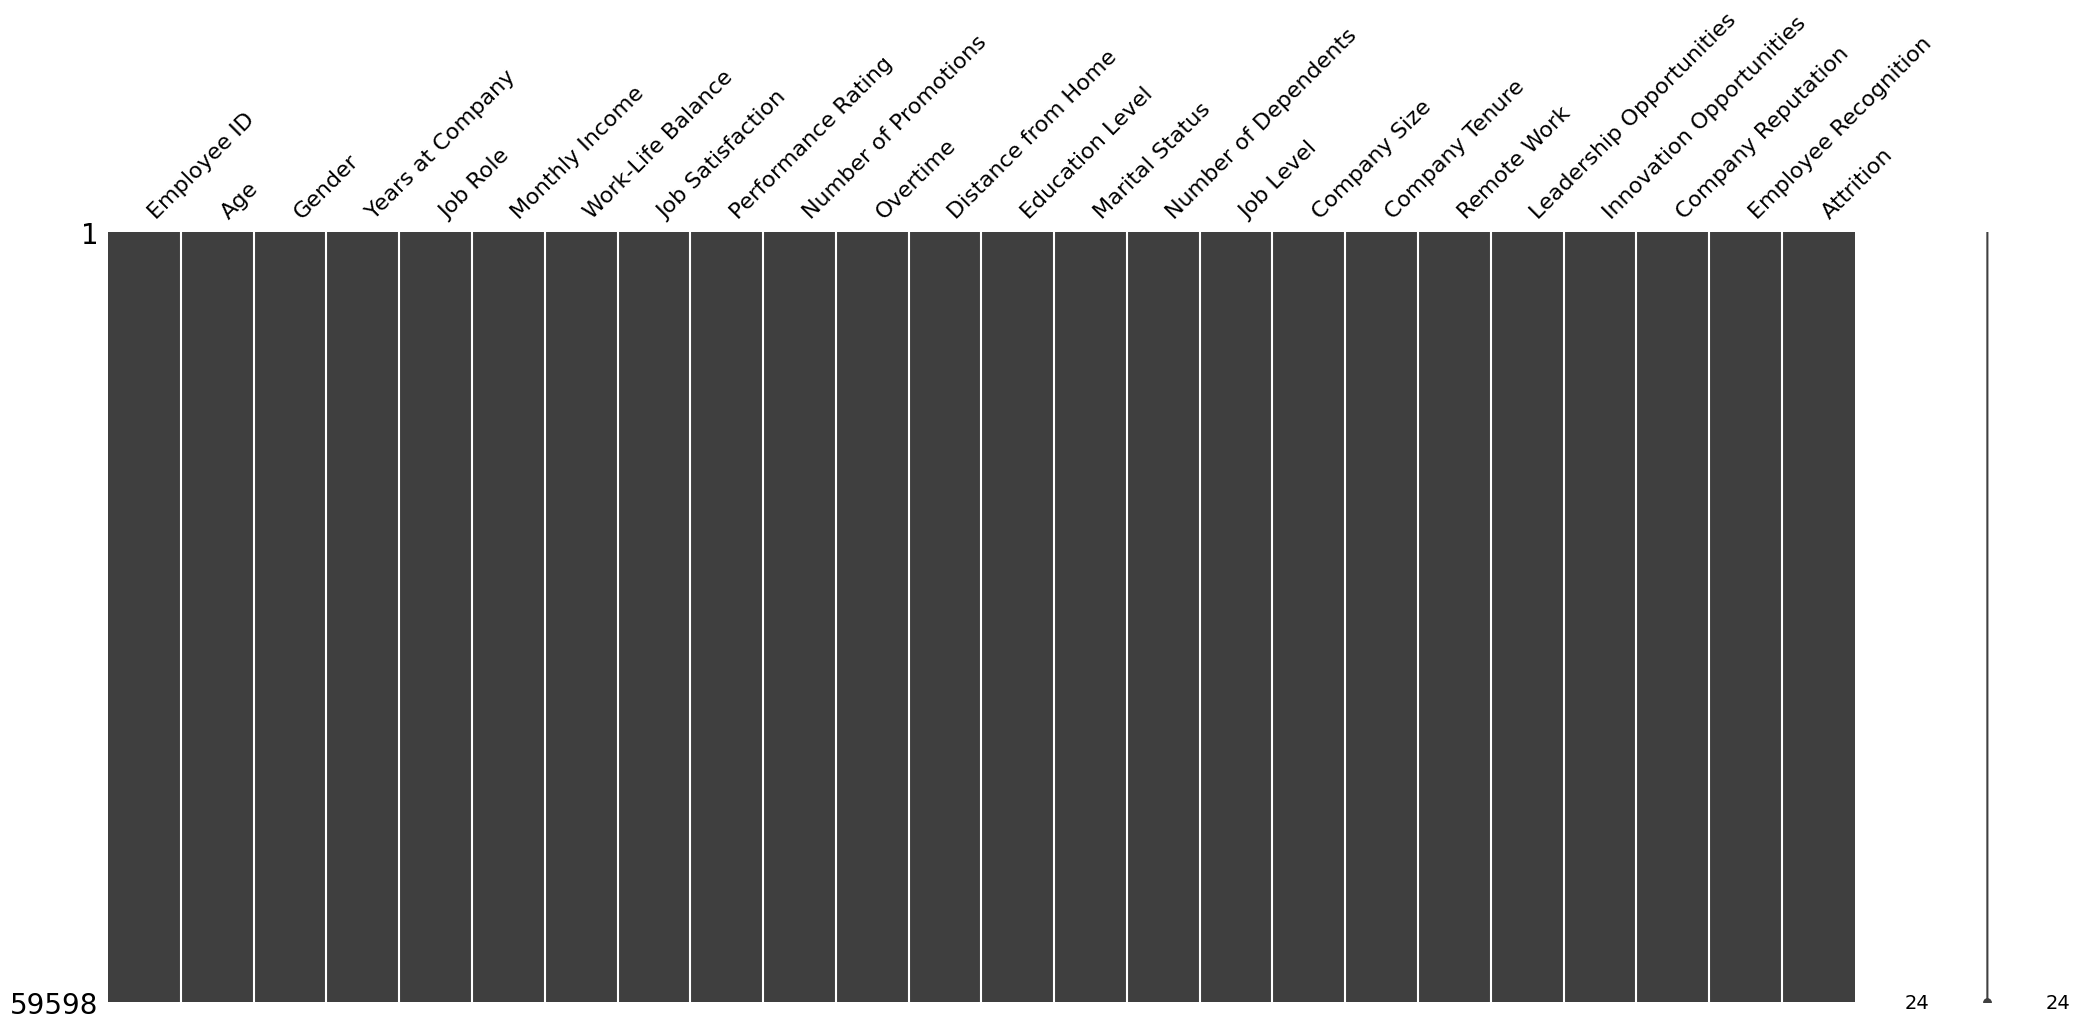

In [82]:
msno.matrix(employees_data)

In [83]:
employees_data.isnull().sum()

,0
Employee ID,0
Age,0
Gender,0
Years at Company,0
Job Role,0
Monthly Income,0
Work-Life Balance,0
Job Satisfaction,0
Performance Rating,0
Number of Promotions,0


No se encuentran valores nulos en nuestro dataset.

##Información adicional

In [84]:
employees_data.describe()

,Employee ID,Age,Years at Company,Monthly Income,Number of Promotions,Distance from Home,Number of Dependents,Company Tenure
count,59598.000000,59598.000000,59598.000000,59598.000000,59598.000000,59598.000000,59598.000000,59598.000000
mean,37227.118729,38.565875,15.753901,7302.397983,0.832578,50.007651,1.648075,55.758415
std,21519.150028,12.079673,11.245981,2151.457423,0.994991,28.466459,1.555689,25.411090
min,1.000000,18.000000,1.000000,1316.000000,0.000000,1.000000,0.000000,2.000000
25%,18580.250000,28.000000,7.000000,5658.000000,0.000000,25.000000,0.000000,36.000000
50%,37209.500000,39.000000,13.000000,7354.000000,1.000000,50.000000,1.000000,56.000000
75%,55876.750000,49.000000,23.000000,8880.000000,2.000000,75.000000,3.000000,76.000000
max,74498.000000,59.000000,51.000000,16149.000000,4.000000,99.000000,6.000000,128.000000


In [85]:
employees_data.value_counts()

,,,,,,,,,,,,,,,,,,,,,,,,count
Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,Overtime,Distance from Home,Education Level,Marital Status,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition,
74498,39,Female,8,Healthcare,6591,Fair,Medium,High,2,Yes,24,High School,Married,2,Entry,Medium,50,No,No,No,Poor,Medium,Left,1
1,56,Male,41,Education,5209,Fair,Very High,Average,0,No,98,Associate Degree,Married,0,Entry,Small,86,No,No,No,Good,Low,Stayed,1
2,46,Female,22,Technology,9099,Fair,Medium,Average,0,No,13,Bachelor’s Degree,Married,0,Entry,Medium,93,No,No,No,Good,High,Left,1
3,32,Male,16,Education,4239,Good,High,Below Average,0,No,54,High School,Single,0,Mid,Small,56,No,No,No,Poor,Low,Stayed,1
4,25,Female,17,Finance,6834,Fair,High,Average,0,Yes,62,PhD,Single,2,Entry,Medium,26,No,No,No,Poor,High,Left,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22,38,Female,7,Healthcare,8466,Poor,Medium,Average,1,Yes,2,Master’s Degree,Married,3,Entry,Small,50,No,No,No,Good,High,Left,1
21,19,Female,6,Healthcare,8244,Good,High,Average,1,Yes,36,Master’s Degree,Divorced,3,Mid,Small,28,No,No,No,Good,Low,Stayed,1
20,55,Female,39,Education,4122,Good,Very High,Below Average,0,No,21,High School,Married,3,Mid,Small,105,Yes,No,No,Excellent,Low,Stayed,1


##Búsqueda de outliers

A continuación analizaremos la presencia de outliers en las columnas numéricas de nuestro dataset, con el objetivo de identificar si alguno de estos valores fuera del promedio puede afectar a nuestro análisis.

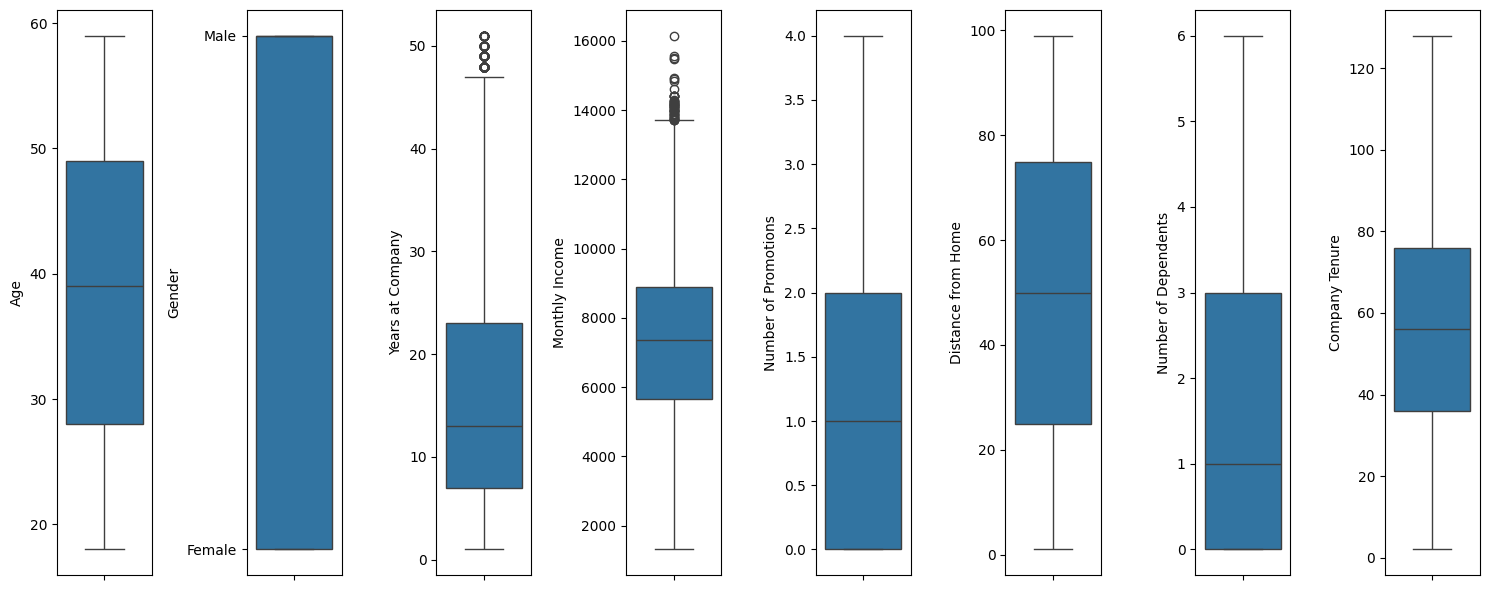

In [86]:
variables = ["Age", "Gender", "Years at Company", "Monthly Income", "Number of Promotions", "Distance from Home", "Number of Dependents", "Company Tenure"]

fig, axes = plt.subplots(1, len(variables), figsize=(15,6))

for ax, variable in zip(axes, variables):
    ax = sns.boxplot( y=variable, data=employees_data, ax=ax)
plt.tight_layout()

Podemos observar que existen valores fuera de la media en las columnas "Years at Company" y "Monthly Income", sin embargo se consideran que estos datos fuera de la norma pueden ser importantes para encontrar correlaciones entre estos valores y la variable a predecir, por lo tanto no se va a realizar ningún tipo de limpieza en estas columnas.

##Visualizaciones

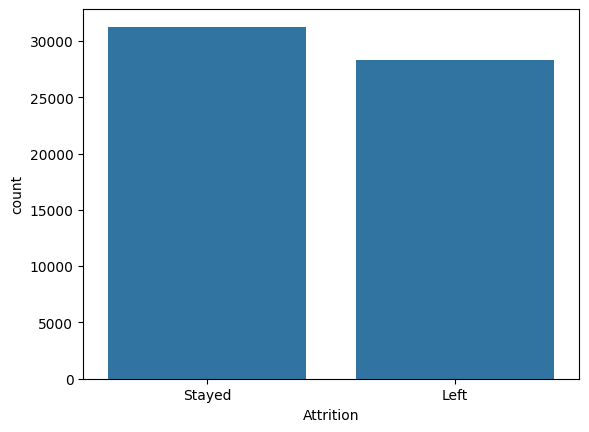

In [87]:
sns.countplot(x="Attrition", data=employees_data)
plt.show()

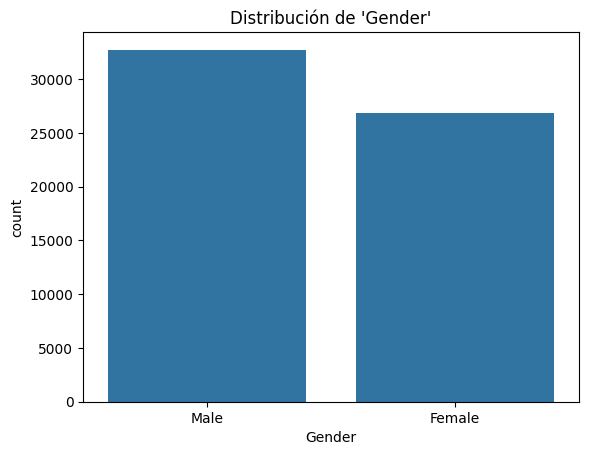

In [88]:
sns.countplot(x="Gender", data=employees_data)
plt.title("Distribución de 'Gender'")
plt.show()

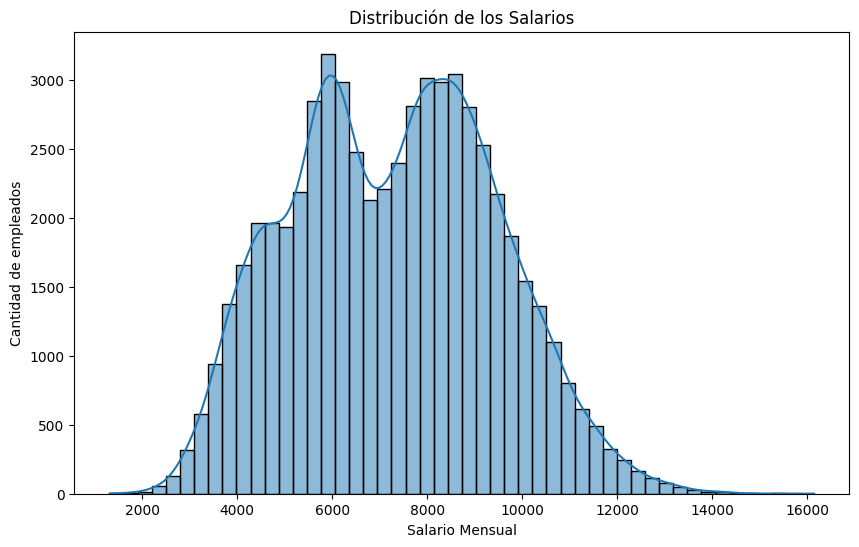

In [89]:
plt.figure(figsize=(10, 6))

sns.histplot(employees_data['Monthly Income'], bins=50, kde=True)

plt.xlabel("Salario Mensual")
plt.ylabel("Cantidad de empleados")
plt.title("Distribución de los Salarios")

plt.show()

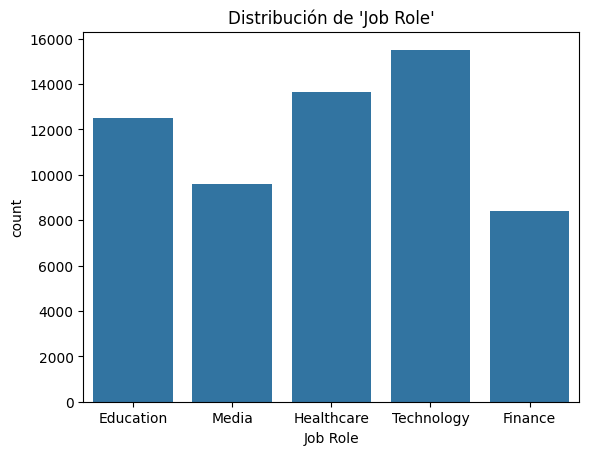

In [90]:
sns.countplot(x="Job Role", data=employees_data)
plt.title("Distribución de 'Job Role'")
plt.show()

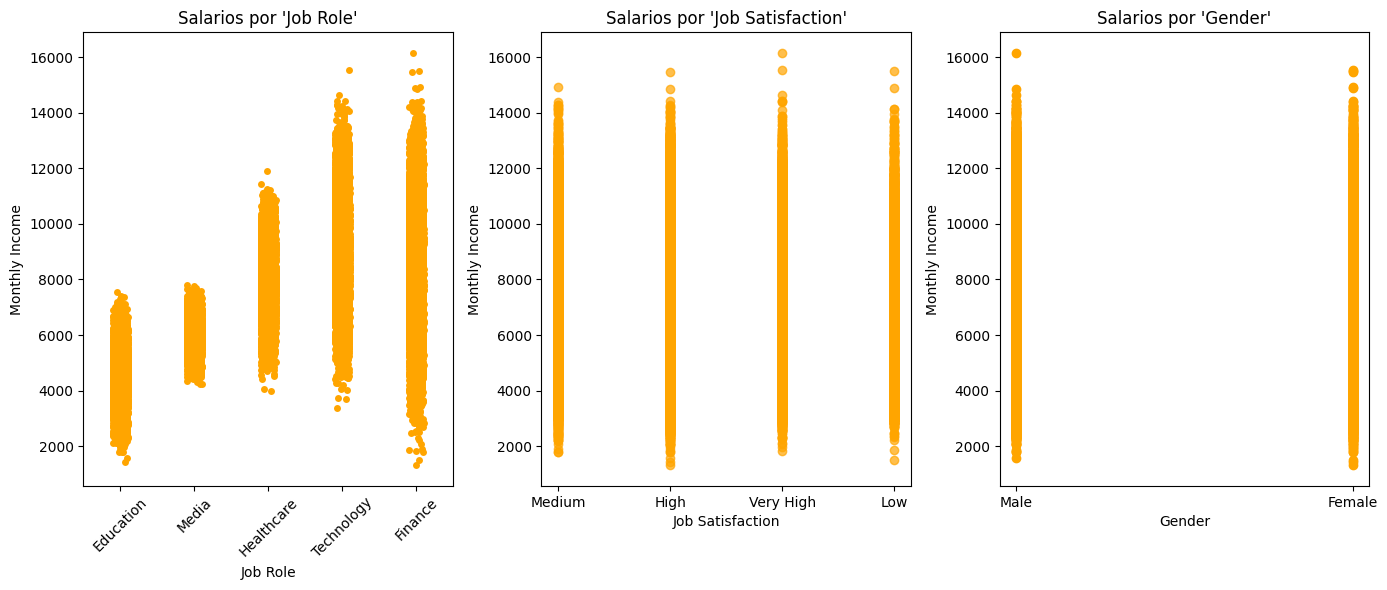

In [91]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 3, 1)
sns.stripplot(x='Job Role', y='Monthly Income', data=employees_data, jitter=True, color='orange')
plt.title("Salarios por 'Job Role'")
plt.xlabel("Job Role")
plt.ylabel("Monthly Income")
plt.xticks(rotation=45)

plt.subplot(1, 3, 2)
plt.scatter(employees_data['Job Satisfaction'], employees_data['Monthly Income'], alpha=0.7, c='orange')
plt.title("Salarios por 'Job Satisfaction'")
plt.xlabel("Job Satisfaction")
plt.ylabel("Monthly Income")

plt.subplot(1, 3, 3)
plt.scatter(employees_data['Gender'], employees_data['Monthly Income'], c='orange')
plt.title("Salarios por 'Gender'")
plt.xlabel("Gender")
plt.ylabel("Monthly Income")

plt.tight_layout()
plt.show()

In [92]:
profile = ProfileReport(employees_data)
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 24/24 [00:08<00:00,  2.92it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

#Preguntas/Hipótesis

##¿Que factores influyen más en la decisión de un empleado de dejar la companía?

###Mapa de calor

En primer lugar vamos a generar un mapa de calor calculando los valores de correlación con la variable 'Attrition'. De esta manera vamos a elegir las variables que mayor indice de correlación tengan para realizar un análisis.

In [93]:
columnas_no_numericas = ["Gender", "Job Role", "Work-Life Balance", "Job Satisfaction", "Performance Rating", "Overtime", "Education Level", "Marital Status",
                                        "Job Level", "Company Size", "Remote Work", "Leadership Opportunities", "Innovation Opportunities", "Company Reputation", "Employee Recognition"]

dummies = pd.get_dummies(employees_data[columnas_no_numericas])
dummies = dummies.astype(int)
dummies

,Gender_Female,Gender_Male,Job Role_Education,Job Role_Finance,Job Role_Healthcare,Job Role_Media,Job Role_Technology,Work-Life Balance_Excellent,Work-Life Balance_Fair,Work-Life Balance_Good,...,Innovation Opportunities_No,Innovation Opportunities_Yes,Company Reputation_Excellent,Company Reputation_Fair,Company Reputation_Good,Company Reputation_Poor,Employee Recognition_High,Employee Recognition_Low,Employee Recognition_Medium,Employee Recognition_Very High
0,0,1,1,0,0,0,0,1,0,0,...,1,0,1,0,0,0,0,0,1,0
1,1,0,0,0,0,1,0,0,0,0,...,1,0,0,1,0,0,0,1,0,0
2,1,0,0,0,1,0,0,0,0,1,...,1,0,0,0,0,1,0,1,0,0
3,1,0,1,0,0,0,0,0,0,1,...,1,0,0,0,1,0,0,0,1,0
4,0,1,1,0,0,0,0,0,1,0,...,1,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59593,1,0,1,0,0,0,0,0,1,0,...,0,1,0,0,0,1,0,0,0,1
59594,0,1,0,0,1,0,0,0,1,0,...,1,0,0,1,0,0,0,0,1,0
59595,1,0,0,0,0,0,1,0,1,0,...,1,0,0,0,1,0,0,0,1,0
59596,0,1,1,0,0,0,0,0,1,0,...,1,0,0,0,1,0,0,1,0,0


In [94]:
employees_data_dummies = employees_data.drop(columnas_no_numericas, axis=1)
employees_data_dummies = pd.concat([employees_data_dummies, dummies], axis=1)
employees_data_dummies

,Employee ID,Age,Years at Company,Monthly Income,Number of Promotions,Distance from Home,Number of Dependents,Company Tenure,Attrition,Gender_Female,...,Innovation Opportunities_No,Innovation Opportunities_Yes,Company Reputation_Excellent,Company Reputation_Fair,Company Reputation_Good,Company Reputation_Poor,Employee Recognition_High,Employee Recognition_Low,Employee Recognition_Medium,Employee Recognition_Very High
0,8410,31,19,5390,2,22,0,89,Stayed,0,...,1,0,1,0,0,0,0,0,1,0
1,64756,59,4,5534,3,21,3,21,Stayed,1,...,1,0,0,1,0,0,0,1,0,0
2,30257,24,10,8159,0,11,3,74,Stayed,1,...,1,0,0,0,0,1,0,1,0,0
3,65791,36,7,3989,1,27,2,50,Stayed,1,...,1,0,0,0,1,0,0,0,1,0
4,65026,56,41,4821,0,71,0,68,Stayed,0,...,1,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59593,37195,50,12,4414,1,66,2,35,Left,1,...,0,1,0,0,0,1,0,0,0,1
59594,6266,18,4,8040,3,42,0,73,Left,0,...,1,0,0,1,0,0,0,0,1,0
59595,54887,22,14,7944,0,34,2,29,Stayed,1,...,1,0,0,0,1,0,0,0,1,0
59596,861,23,8,2931,0,62,0,9,Left,0,...,1,0,0,0,1,0,0,1,0,0


Para el caso de nuestra variable a predecir, representada por la columna "Attrition", tenemos dos valores posibles: "Stayed" y "Left" los cuáles vamos a reemplazar por 0 y 1 respectivamente.

In [95]:
# Stayed: 0, Left: 1

employees_data_dummies["Attrition"] = employees_data_dummies["Attrition"].replace({"Stayed": 0, "Left": 1})
employees_data_dummies

,Employee ID,Age,Years at Company,Monthly Income,Number of Promotions,Distance from Home,Number of Dependents,Company Tenure,Attrition,Gender_Female,...,Innovation Opportunities_No,Innovation Opportunities_Yes,Company Reputation_Excellent,Company Reputation_Fair,Company Reputation_Good,Company Reputation_Poor,Employee Recognition_High,Employee Recognition_Low,Employee Recognition_Medium,Employee Recognition_Very High
0,8410,31,19,5390,2,22,0,89,0,0,...,1,0,1,0,0,0,0,0,1,0
1,64756,59,4,5534,3,21,3,21,0,1,...,1,0,0,1,0,0,0,1,0,0
2,30257,24,10,8159,0,11,3,74,0,1,...,1,0,0,0,0,1,0,1,0,0
3,65791,36,7,3989,1,27,2,50,0,1,...,1,0,0,0,1,0,0,0,1,0
4,65026,56,41,4821,0,71,0,68,0,0,...,1,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59593,37195,50,12,4414,1,66,2,35,1,1,...,0,1,0,0,0,1,0,0,0,1
59594,6266,18,4,8040,3,42,0,73,1,0,...,1,0,0,1,0,0,0,0,1,0
59595,54887,22,14,7944,0,34,2,29,0,1,...,1,0,0,0,1,0,0,0,1,0
59596,861,23,8,2931,0,62,0,9,1,0,...,1,0,0,0,1,0,0,1,0,0


In [96]:
corr_matrix = employees_data_dummies.corr(method="pearson").abs()
attrition_corr = corr_matrix[['Attrition']].sort_values(by='Attrition', ascending=False)

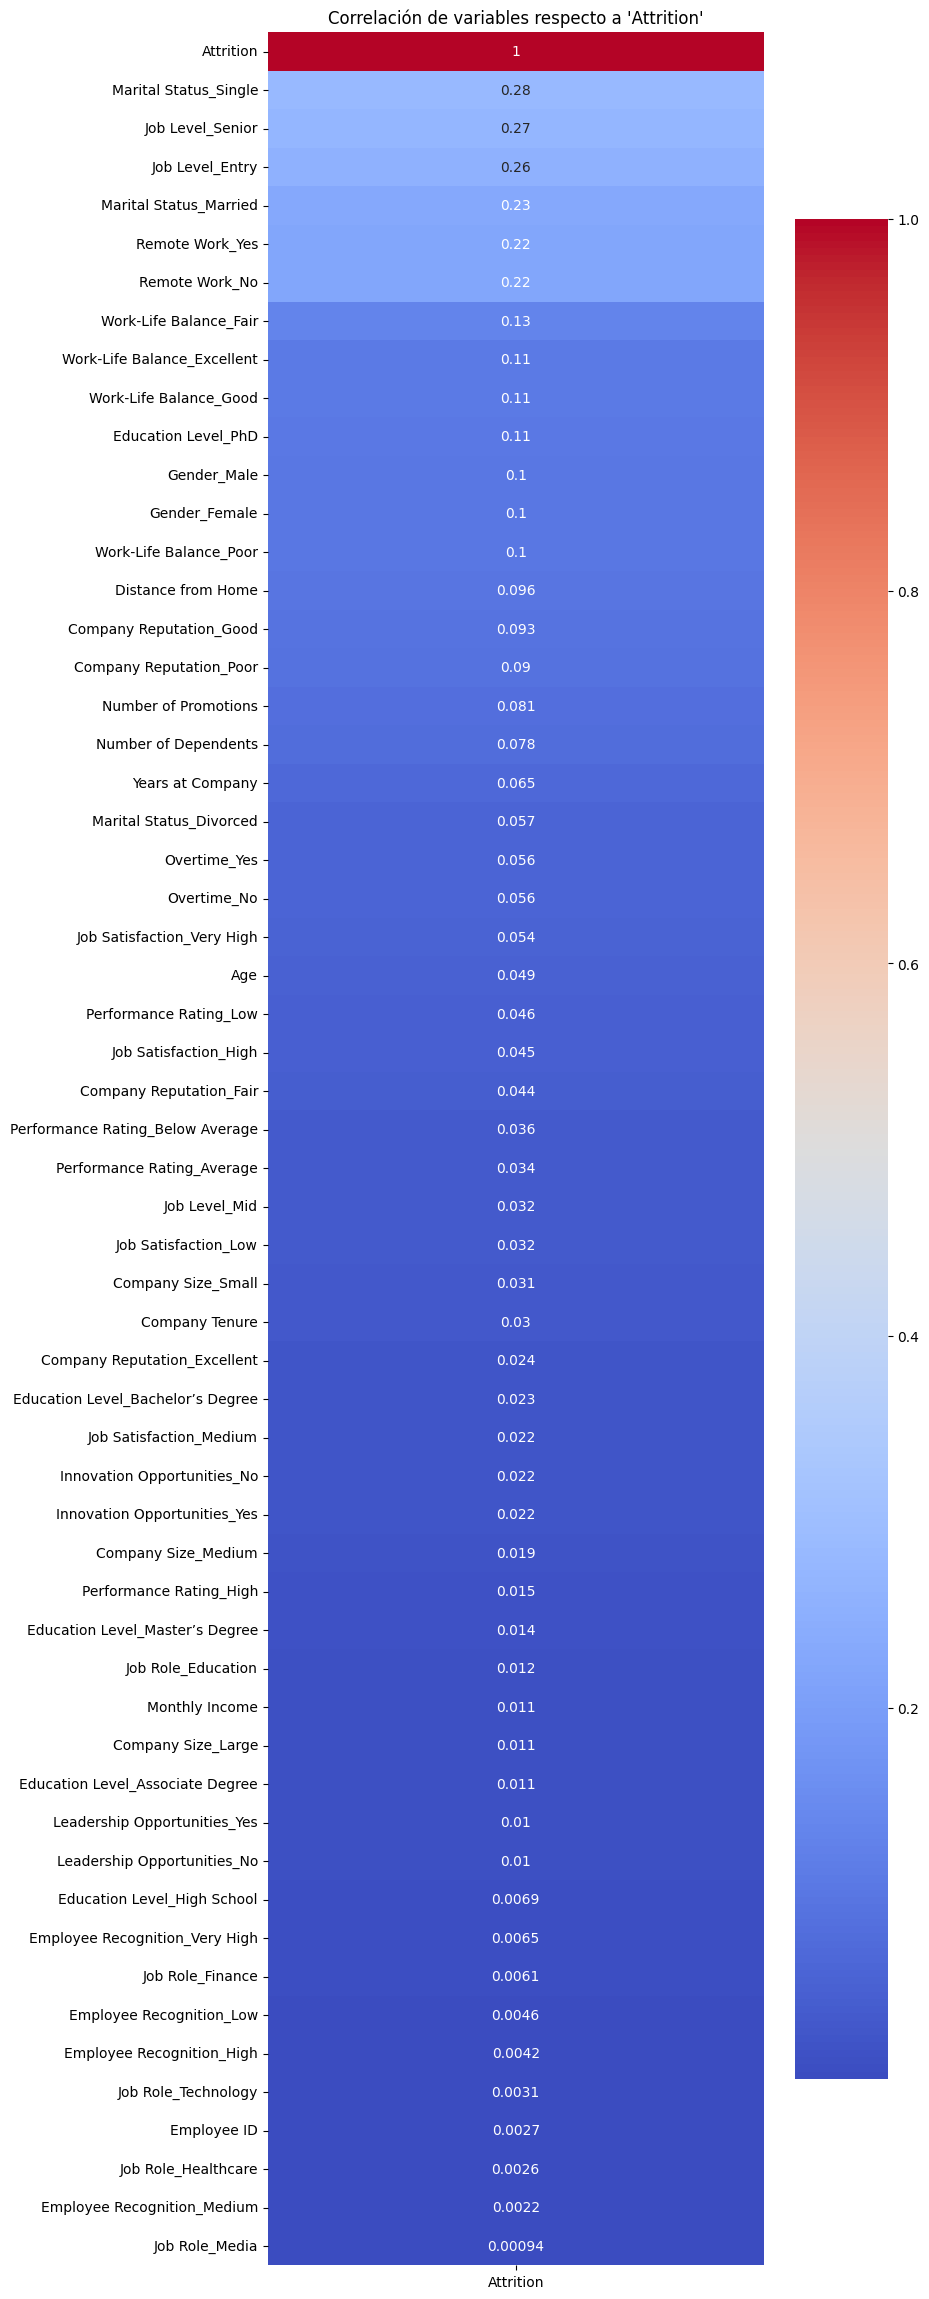

In [97]:
plt.figure(figsize=(8, len(attrition_corr)*0.5))

sns.heatmap(attrition_corr, annot=True, cmap='coolwarm')

plt.title("Correlación de variables respecto a 'Attrition'")
plt.show()

In [98]:
attrition_corr.head(20)

,Attrition
Attrition,1.000000
Marital Status_Single,0.282988
Job Level_Senior,0.273526
Job Level_Entry,0.256010
Marital Status_Married,0.229132
Remote Work_Yes,0.220447
Remote Work_No,0.220447
Work-Life Balance_Fair,0.130849
Work-Life Balance_Excellent,0.110028
Work-Life Balance_Good,0.109116


Las variables que mayor valor de correlación tienen son: Marital Status, Job Level, Remote Work, Worf-Life Balance y Education Level.

### Marital Status

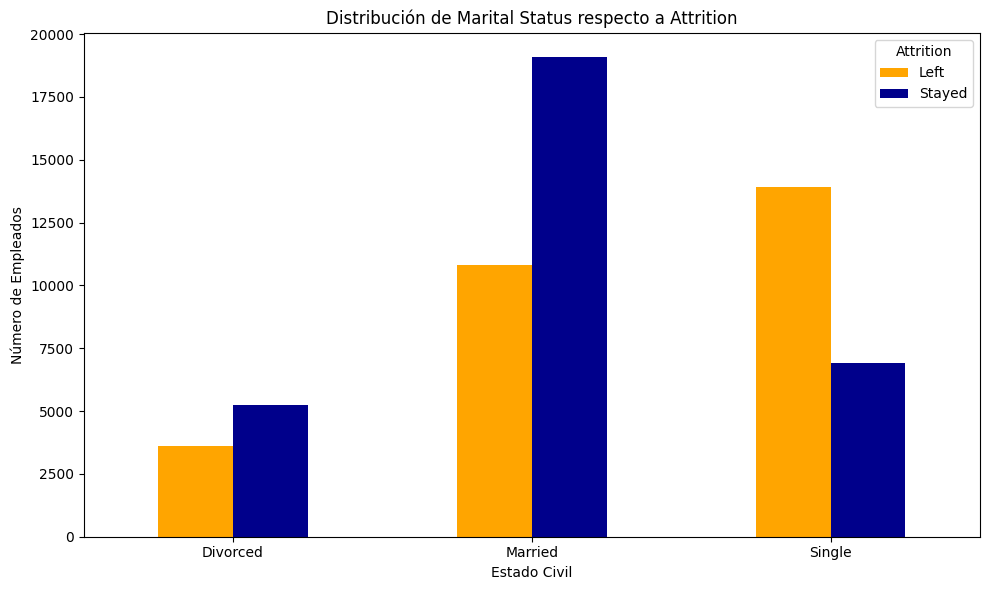

In [99]:
marital_attrition_counts = employees_data.groupby(['Marital Status', 'Attrition']).size().unstack()

marital_attrition_counts.plot(kind='bar', stacked=False, figsize=(10, 6), color=['orange', 'darkblue'])

plt.title('Distribución de Marital Status respecto a Attrition')
plt.xlabel('Estado Civil')
plt.ylabel('Número de Empleados')
plt.xticks(rotation=0)
plt.legend(title='Attrition', loc='upper right', labels=['Left', 'Stayed'])

plt.tight_layout()
plt.show()

In [100]:
ct = pd.crosstab(employees_data['Marital Status'], employees_data['Attrition'], normalize='index')
print(ct)

Attrition           Left    Stayed
Marital Status                    
Divorced        0.407002  0.592998
Married         0.361475  0.638525
Single          0.668251  0.331749


Podemos ver que para los casos Divorced y Married es mayor la tendencia a quedarse. En cambio, en el caso Single es muy marcada la tendencia a dejar la compañía.

###Job Level

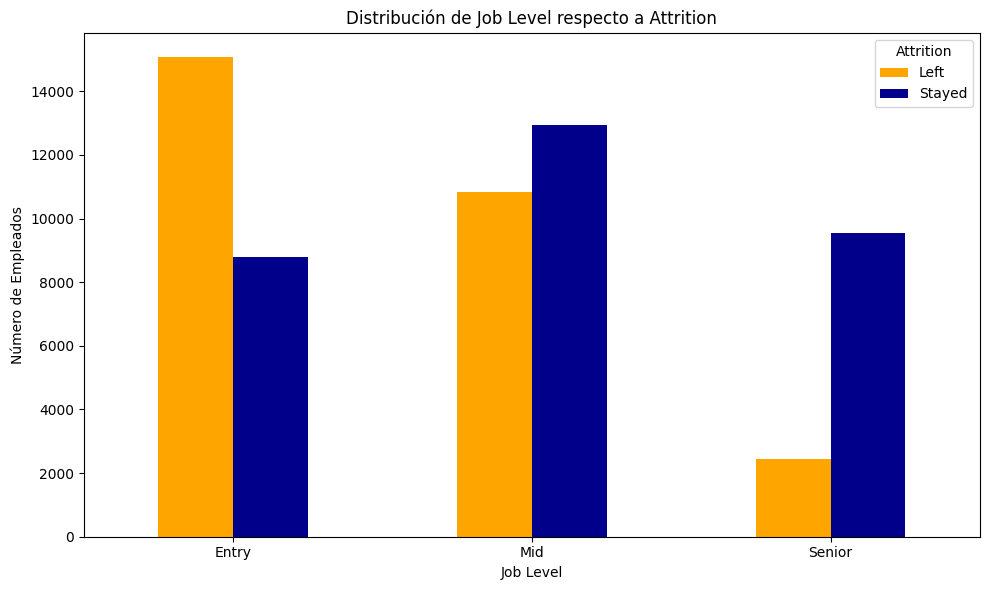

In [101]:
job_level_counts = employees_data.groupby(['Job Level', 'Attrition']).size().unstack()

job_level_counts.plot(kind='bar', stacked=False, figsize=(10, 6), color=['orange', 'darkblue'])

plt.title('Distribución de Job Level respecto a Attrition')
plt.xlabel('Job Level')
plt.ylabel('Número de Empleados')
plt.xticks(rotation=0)
plt.legend(title='Attrition', loc='upper right', labels=['Left', 'Stayed'])

plt.tight_layout()
plt.show()

In [102]:
ct = pd.crosstab(employees_data['Job Level'], employees_data['Attrition'], normalize='index')
print(ct)

Attrition      Left    Stayed
Job Level                    
Entry      0.631919  0.368081
Mid        0.455648  0.544352
Senior     0.203122  0.796878


Se puede ver que para el valor de Job Level "Senior" existe una gran tendencia marcada a quedarse en la compañía, mientras que en el nivel "Entry" es mayor la tendencia a irse.

###Remote Work

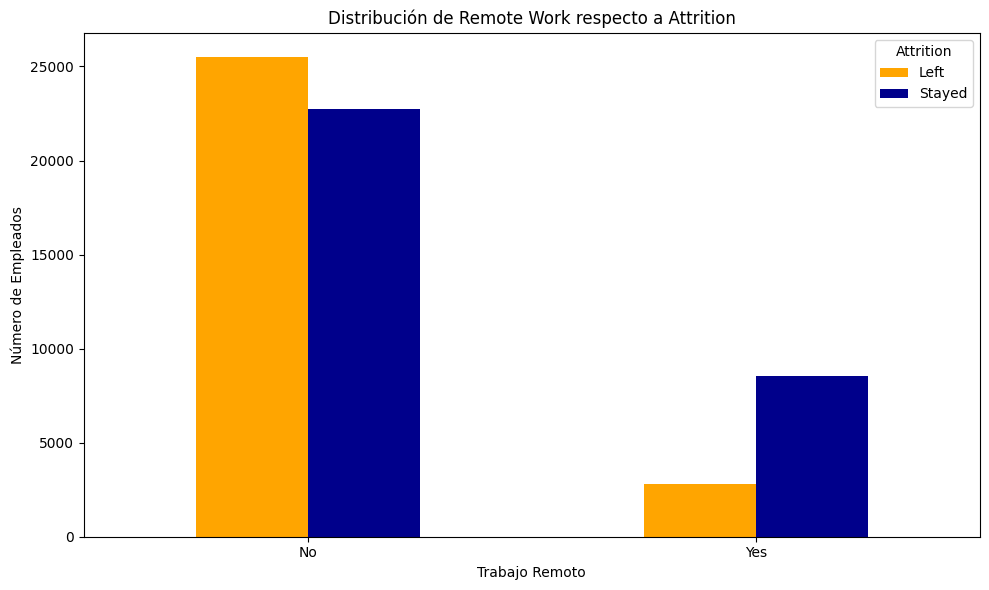

In [103]:
remote_work_counts = employees_data.groupby(['Remote Work', 'Attrition']).size().unstack()

remote_work_counts.plot(kind='bar', stacked=False, figsize=(10, 6), color=['orange', 'darkblue'])

plt.title('Distribución de Remote Work respecto a Attrition')
plt.xlabel('Trabajo Remoto')
plt.ylabel('Número de Empleados')
plt.xticks(rotation=0)
plt.legend(title='Attrition', loc='upper right', labels=['Left', "Stayed"])

plt.tight_layout()
plt.show()

In [104]:
ct = pd.crosstab(employees_data['Remote Work'], employees_data['Attrition'], normalize='index')
print(ct)

Attrition        Left    Stayed
Remote Work                    
No           0.528908  0.471092
Yes          0.248613  0.751387


En este caso no existe un desbalanceo entre los empleados para el caso "No", mientras que si existe una clara diferencia para el caso "Yes", dónde es mayor la cantidad de empleados en estado "Stayed". Esto nos sugiere que los empleados que trabajan en condición de remoto son más propensos a quedarse en la compañía.

###Work-Life Balance

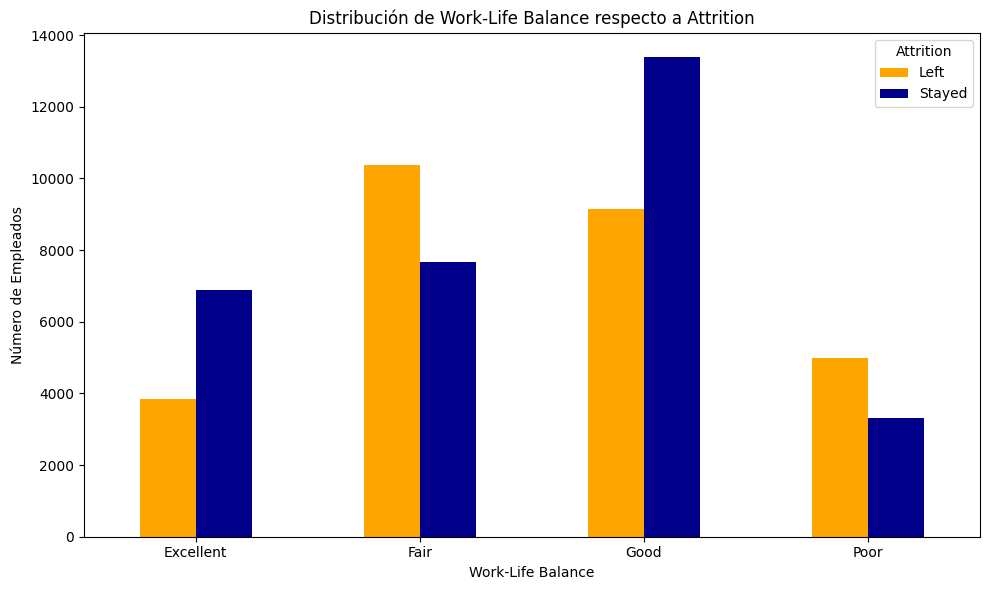

In [105]:
work_life_balance_counts = employees_data.groupby(['Work-Life Balance', 'Attrition']).size().unstack()

work_life_balance_counts.plot(kind='bar', stacked=False, figsize=(10, 6), color=['orange', 'darkblue'])

plt.title('Distribución de Work-Life Balance respecto a Attrition')
plt.xlabel('Work-Life Balance')
plt.ylabel('Número de Empleados')
plt.xticks(rotation=0)
plt.legend(title='Attrition', loc='upper right', labels=['Left', "Stayed"])

plt.tight_layout()
plt.show()

In [106]:
ct = pd.crosstab(employees_data['Work-Life Balance'], employees_data['Attrition'], normalize='index')
print(ct)

Attrition              Left    Stayed
Work-Life Balance                    
Excellent          0.358149  0.641851
Fair               0.574643  0.425357
Good               0.405584  0.594416
Poor               0.601084  0.398916


Vemos que existe una mayor tendencia a quedarse para los casos "Excellent" y "Fair", mientras que una mayor tendencia a irse para los casos "Good" y "Poor"

###Education Level

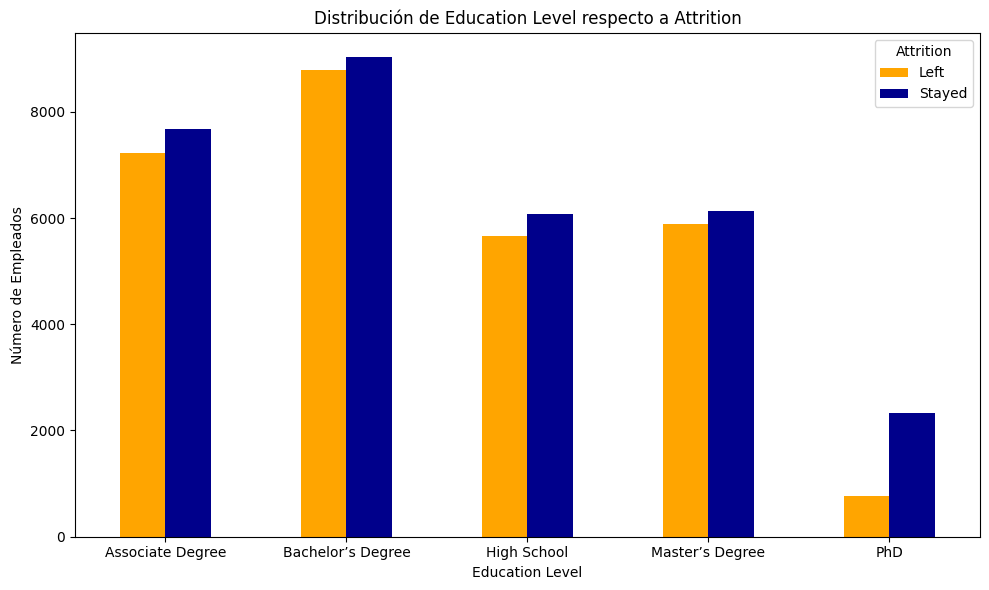

In [107]:
education_level_counts = employees_data.groupby(['Education Level', 'Attrition']).size().unstack()

education_level_counts.plot(kind='bar', stacked=False, figsize=(10, 6), color=['orange', 'darkblue'])

plt.title('Distribución de Education Level respecto a Attrition')
plt.xlabel('Education Level')
plt.ylabel('Número de Empleados')
plt.xticks(rotation=0)
plt.legend(title='Attrition', loc='upper right', labels=['Left', "Stayed"])

plt.tight_layout()
plt.show()

In [108]:
ct = pd.crosstab(employees_data['Education Level'], employees_data['Attrition'], normalize='index')
print(ct)

Attrition              Left    Stayed
Education Level                      
Associate Degree   0.484747  0.515253
Bachelor’s Degree  0.493156  0.506844
High School        0.482465  0.517535
Master’s Degree    0.489268  0.510732
PhD                0.248624  0.751376


En esta variable vemos una muy marcada tendencia a quedarse en el caso de los empleados que poseen un PhD.

###Análisis Multivariado

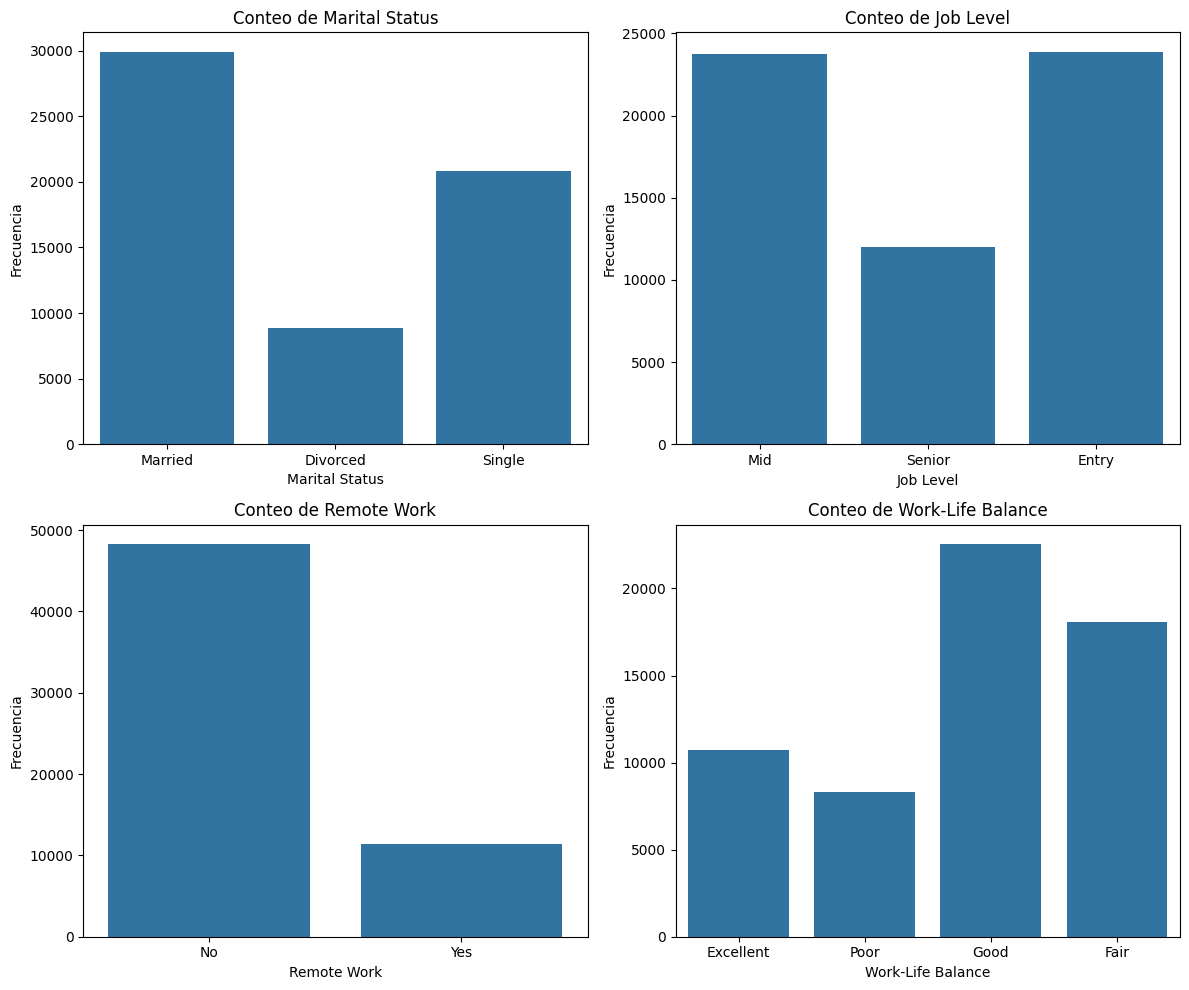

In [109]:
cols = ["Marital Status", "Job Level", "Remote Work", "Work-Life Balance", "Education Level", "Attrition"]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))

axes_flat = axes.flatten()

for ax, col in zip(axes_flat, cols):
    sns.countplot(x=col, data=employees_data, ax=ax)
    ax.set_title(f'Conteo de {col}')
    ax.set_ylabel('Frecuencia')
    ax.tick_params(rotation=0)

for ax in axes_flat[len(cols):]:
    ax.set_visible(False)

fig.tight_layout()

###Conclusiones

Podemos obtener las siguientes conclusiones:



*   Los empleados solteros son más propensos a irse, mientras que los que están casados son más propensos a quedarse la compañía.
*   Los empleados con un Job Level "Senior" a quedarse, mientras que los tienen un nivel "Entry" son más propensos a irse.
*   Los empleados que trabajan en condición de remoto son más propensos a quedarse en la companía.
*   Los empleados con un work-life balance "Excellent" y "Fair" son más propensos a quedarse, mientras que los empleados con un balance "Poor" y "Good" tienden a irse de la companía.
*   Los empleados que poseen un doctorado (PhD) son claramente más propensos a quedarse en la companía.



##¿Existe alguna relación entre el desempeño del empleado y su probabilidad de quedarse o irse?

Para realizar este análisis se consideran importantes las siguientes columnas relacionadas con el desempeño del empleado: "Years at Company", "Performance Rating", "Number of Promotions", "Overtime", "Employee Recognition".

###Years at Company

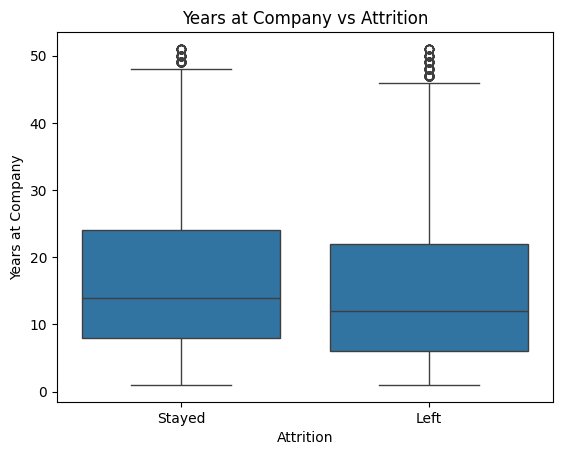

In [110]:
plt.figure()
sns.boxplot(x="Attrition", y="Years at Company", data=employees_data)
plt.title("Years at Company vs Attrition")
plt.show()

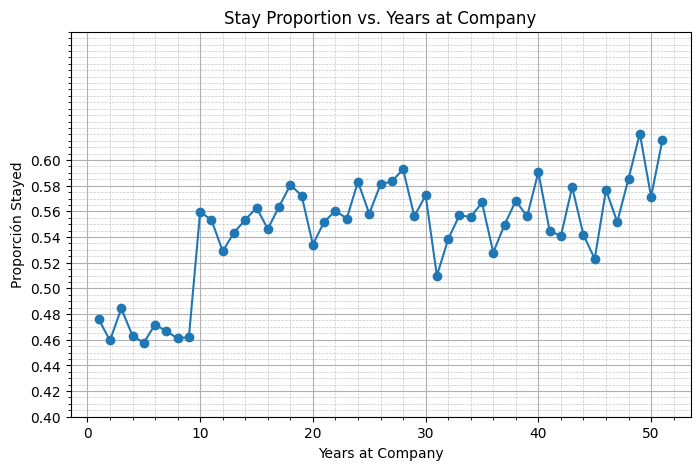

In [111]:
stay_rate = (
    employees_data.groupby('Years at Company')['Attrition']
      .apply(lambda s: (s == 'Stayed').mean())
      .reset_index(name='Stay_Proportion')
)

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(stay_rate['Years at Company'],
        stay_rate['Stay_Proportion'],
        marker='o')

ax.set_ylim(0.4, 0.7)

yticks = np.linspace(0.4, 0.6, 11)
ax.set_yticks(yticks)

ax.yaxis.set_minor_locator(plt.MultipleLocator(0.01))
ax.minorticks_on()

ax.grid(which='major', linestyle='-', linewidth=0.8)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.7)

ax.set_title('Stay Proportion vs. Years at Company')
ax.set_xlabel('Years at Company')
ax.set_ylabel('Proporción Stayed')

plt.show()

In [112]:
ct = pd.crosstab(employees_data['Years at Company'], employees_data['Attrition'], normalize='index')
print(ct)

Attrition             Left    Stayed
Years at Company                    
1                 0.524164  0.475836
2                 0.540563  0.459437
3                 0.515638  0.484362
4                 0.536924  0.463076
5                 0.542345  0.457655
6                 0.528157  0.471843
7                 0.533390  0.466610
8                 0.538910  0.461090
9                 0.537917  0.462083
10                0.440336  0.559664
11                0.446690  0.553310
12                0.470988  0.529012
13                0.456543  0.543457
14                0.446597  0.553403
15                0.437126  0.562874
16                0.453650  0.546350
17                0.436306  0.563694
18                0.419420  0.580580
19                0.427655  0.572345
20                0.465934  0.534066
21                0.448113  0.551887
22                0.439506  0.560494
23                0.445626  0.554374
24                0.416894  0.583106
25                0.441838  0.558162
2

Se podría afirmar que en general, un empleado con más años en la compañía tiene más probabilidades de quedarse que de dejarla.

###Performance Rating

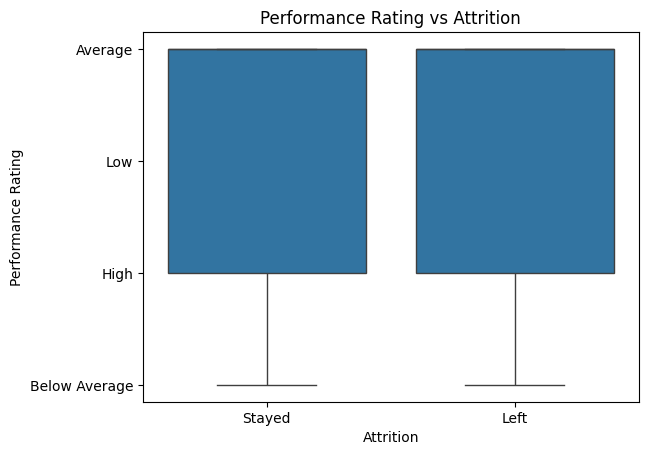

In [113]:
plt.figure()
sns.boxplot(x="Attrition", y="Performance Rating", data=employees_data)
plt.title("Performance Rating vs Attrition")
plt.show()

In [114]:
ct = pd.crosstab(employees_data['Performance Rating'], employees_data['Attrition'], normalize='index')
print(ct)

Attrition               Left    Stayed
Performance Rating                    
Average             0.461519  0.538481
Below Average       0.518101  0.481899
High                0.460717  0.539283
Low                 0.575254  0.424746


Podemos destacar que empleados con un Performance "Low" tienen más tendencia a dejar la compañía que a quedarse en ella.

###Number of Promotions

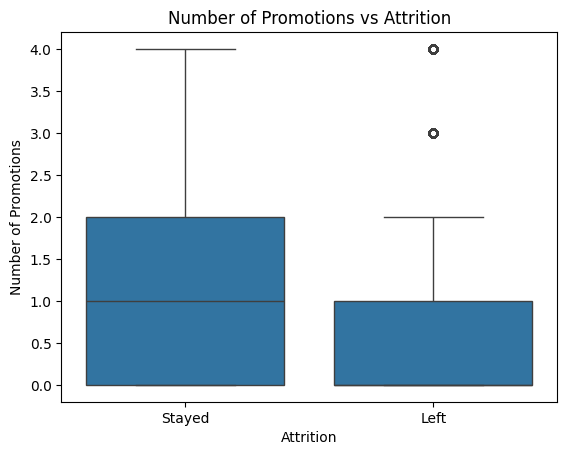

In [115]:
plt.figure()
sns.boxplot(x="Attrition", y="Number of Promotions", data=employees_data)
plt.title("Number of Promotions vs Attrition")
plt.show()

In [116]:
ct = pd.crosstab(employees_data['Number of Promotions'], employees_data['Attrition'], normalize='index')
print(ct)

Attrition                 Left    Stayed
Number of Promotions                    
0                     0.493270  0.506730
1                     0.490210  0.509790
2                     0.490720  0.509280
3                     0.253621  0.746379
4                     0.228426  0.771574


En este caso se observa que casi todos los empleados que se fueron se concentran en el nivel dos o inferior según el número de promociones. A mayor número de promociones, existe una tendencia clara a quedarse en la compañía, sobre todo en los valores tres y cuatro.

###Overtime

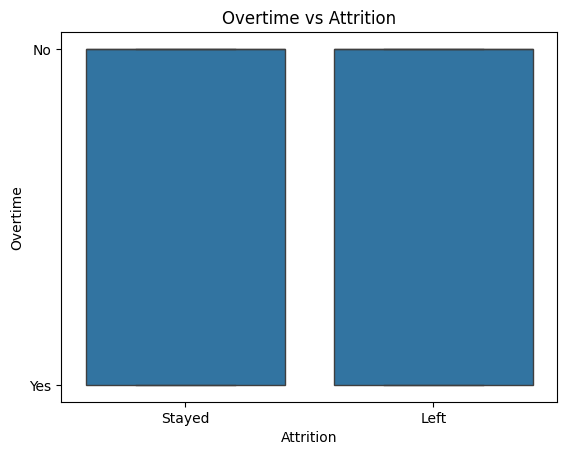

In [117]:
plt.figure()
sns.boxplot(x="Attrition", y="Overtime", data=employees_data)
plt.title("Overtime vs Attrition")
plt.show()

In [118]:
ct = pd.crosstab(employees_data['Overtime'], employees_data['Attrition'], normalize='index')
print(ct)

Attrition      Left    Stayed
Overtime                     
No         0.456137  0.543863
Yes        0.515424  0.484576


Existe una leve tendencia a quedarse en los casos en dónde los empleados no realizan trabajo fuera de horario.

###Análisis Multivariado

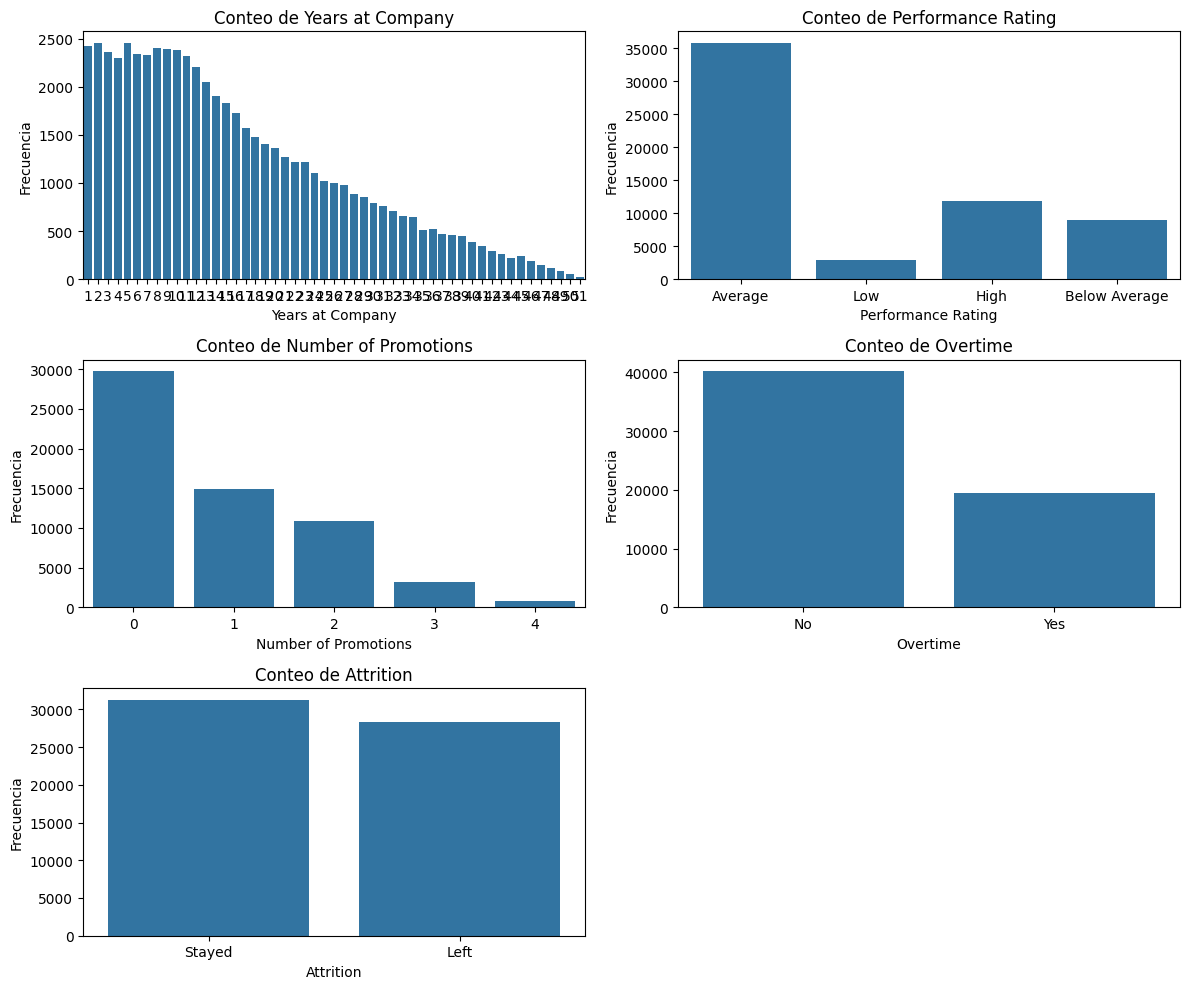

In [119]:
cols = ["Years at Company", "Performance Rating", "Number of Promotions", "Overtime", "Attrition"]

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 10))

axes_flat = axes.flatten()

for ax, col in zip(axes_flat, cols):
    sns.countplot(x=col, data=employees_data, ax=ax)
    ax.set_title(f'Conteo de {col}')
    ax.set_ylabel('Frecuencia')
    ax.tick_params(rotation=0)

for ax in axes_flat[len(cols):]:
    ax.set_visible(False)

fig.tight_layout()

###Conclusiones

Luego de los gráficos realizados podemos observar lo siguiente:

*   Para Number of Promotions, en el gráfico realizado vemos que para los casos 0, 1 y 2 la proporción de empleados que se fueron o se quedaron es bastante balanceada y para niveles más altos es mucha mayor la tendencia a quedarse.
*   Para Performance Rating, vemos una tendencia a irse en los casos de valores "Low"





##¿Los empleados que tienen mayores oportunidades de liderazgo e innovación tienen menos probabilidades de irse?

###Leadership Opportunities

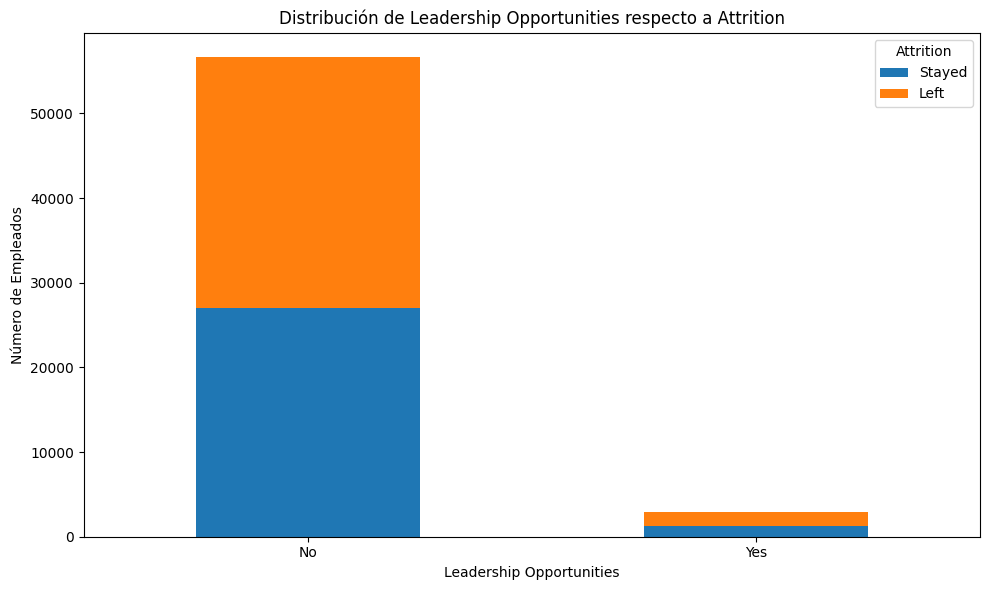

In [120]:
leadership_counts = employees_data.groupby(['Leadership Opportunities', 'Attrition']).size().unstack()

leadership_counts.plot(kind='bar', stacked=True, figsize=(10, 6))

plt.title('Distribución de Leadership Opportunities respecto a Attrition')
plt.xlabel('Leadership Opportunities')
plt.ylabel('Número de Empleados')
plt.xticks(rotation=0)
plt.legend(title='Attrition', loc='upper right', labels=['Stayed', 'Left'])

plt.tight_layout()
plt.show()

In [121]:
ct = pd.crosstab(employees_data['Leadership Opportunities'], employees_data['Attrition'], normalize='index')
print(ct)

Attrition                     Left    Stayed
Leadership Opportunities                    
No                        0.476641  0.523359
Yes                       0.453050  0.546950


Lo primero que se puede observar es que es una proporción muy pequeña de empleados los que se tienen oportunidades de liderazgo en cuánto a los que no tienen.

Si bien a simple vista no podemos visualizar un gran desbalanceo en cuánto a empleados que se fueron y los que se quedaron, si se puede afirmar que existe una leve tendencia hacia el valor "Stayed" cuando los empleados tienen oportunidades de liderazgo, con un valor de 54%, a diferencia de un 52% en el caso de los empleados que no tuvieron oportunidades.

###Innovation Opportunities

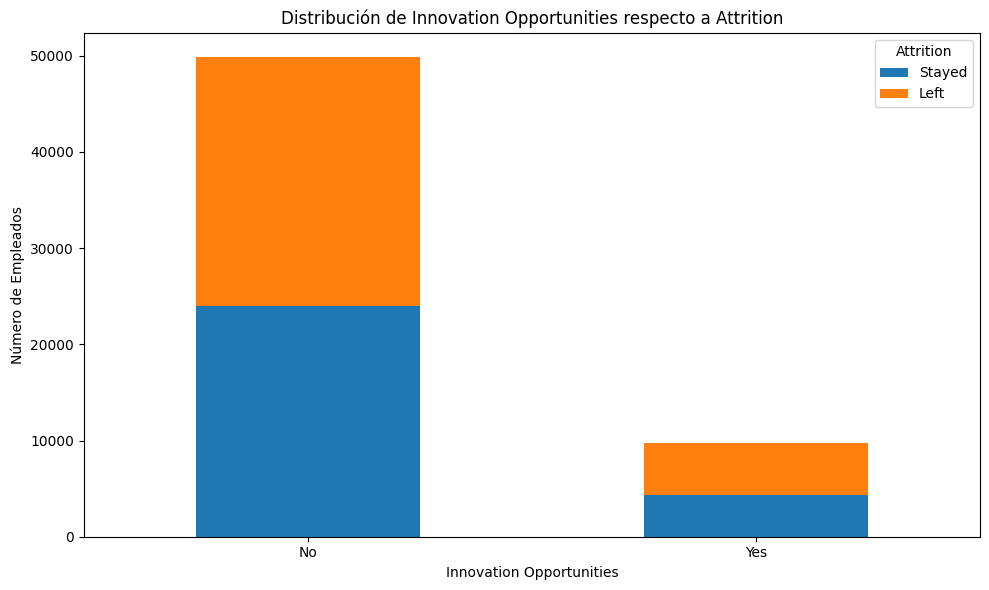

In [122]:
innovation_counts = employees_data.groupby(['Innovation Opportunities', 'Attrition']).size().unstack()

innovation_counts.plot(kind='bar', stacked=True, figsize=(10, 6))

plt.title('Distribución de Innovation Opportunities respecto a Attrition')
plt.xlabel('Innovation Opportunities')
plt.ylabel('Número de Empleados')
plt.xticks(rotation=0)
plt.legend(title='Attrition', loc='upper right', labels=['Stayed', 'Left'])

plt.tight_layout()
plt.show()

In [123]:
ct = pd.crosstab(employees_data['Innovation Opportunities'], employees_data['Attrition'], normalize='index')
print(ct)

Attrition                     Left    Stayed
Innovation Opportunities                    
No                        0.480228  0.519772
Yes                       0.451098  0.548902


De manera similar podemos ver a simple vista que los empleados con oportunidades de innovación son una proporción pequeña comparada al total.

Otra vez podemos ver una leve tendencia a quedarse en los casos en los que los empleados tienen oportunidad de innovación (54% vs 51%).

###Análisis Multivariado

In [124]:
#Le damos valores numéricos a las variables categóricas de interés para poder realizar nuestro análisis.

df = employees_data.copy()
df['Leadership Opportunities'] = df['Leadership Opportunities'].replace({"Yes": 1, "No": 0})
df['Innovation Opportunities'] = df['Innovation Opportunities'].replace({"Yes": 1, "No": 0})

In [125]:
ct_counts = pd.crosstab(
    [df['Leadership Opportunities'], df['Innovation Opportunities']],
    df['Attrition']
)

ct_props = ct_counts.div(ct_counts.sum(axis=1), axis=0)

print(ct_counts)
print(ct_props)

Attrition                                           Left  Stayed
Leadership Opportunities Innovation Opportunities               
0                        0                         22849   24606
                         1                          4167    5058
1                        0                          1112    1328
                         1                           210     268
Attrition                                              Left    Stayed
Leadership Opportunities Innovation Opportunities                    
0                        0                         0.481488  0.518512
                         1                         0.451707  0.548293
1                        0                         0.455738  0.544262
                         1                         0.439331  0.560669


Podemos ver como existe una tendencia de quedarse del 56% en los casos en los que los empleados tienen ambas cosas: oportunidad de liderazgo y oportunidad de innovación, aunque son una proporción muy pequeña respecto del total de empleados.

###Conclusiones

Se puede afirmar que los empleados que tienen mayores oportunidades de liderazgo e innovación tienen menos probabilidades de irse, aunque son muy pocos los empleados que pueden acceder a estas oportunidades

#Encoding

Antes de realizar cualquier análisis sobre los tipos de datos para usar en nuestros modelos, vamos a dividir el dataset en conjuntos de entrenamiento y de testeo.

In [126]:
X = employees_data.drop(columns=['Attrition'])
y = employees_data['Attrition']

In [127]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Utilizando el análisis realizado en las hipótesis planteadas, vamos a quedarnos con las columnas de interés que nos sean de utilidad para los distintos modelos.

In [128]:
important_cols = ["Marital Status", "Job Level", "Remote Work", "Work-Life Balance", "Education Level", "Number of Promotions", "Performance Rating", "Leadership Opportunities", "Innovation Opportunities"]

to_drop = [c for c in X_train.columns if c not in important_cols]

X_train = X_train.drop(columns=to_drop)
X_test = X_test.drop(columns=to_drop)

In [129]:
X_train.nunique()

,0
Work-Life Balance,4
Performance Rating,4
Number of Promotions,5
Education Level,5
Marital Status,3
Job Level,3
Remote Work,2
Leadership Opportunities,2
Innovation Opportunities,2


In [130]:
X_train.dtypes

,0
Work-Life Balance,object
Performance Rating,object
Number of Promotions,int64
Education Level,object
Marital Status,object
Job Level,object
Remote Work,object
Leadership Opportunities,object
Innovation Opportunities,object


Podemos ver que existen varias columnas con datos no numéricos, por lo que vamos a transformar estas columnas a otras columnas con valores "0" o "1" para poder utilizarlas más adelante en nuestro análisis. Para ello vamos a crear una función.

In [131]:
def encode(df, columns):

  dummies = pd.get_dummies(df[columns])
  dummies = dummies.astype(int)

  df = df.drop(columns, axis=1)
  df = pd.concat([df, dummies], axis=1)

  return df

In [132]:
columnas_no_numericas = ["Work-Life Balance", "Performance Rating", "Education Level", "Marital Status", "Job Level", "Remote Work", "Leadership Opportunities", "Innovation Opportunities"]

X_train_encoded = encode(X_train, columnas_no_numericas)
X_test_encoded = encode(X_test, columnas_no_numericas)

In [133]:
X_train_encoded

,Number of Promotions,Work-Life Balance_Excellent,Work-Life Balance_Fair,Work-Life Balance_Good,Work-Life Balance_Poor,Performance Rating_Average,Performance Rating_Below Average,Performance Rating_High,Performance Rating_Low,Education Level_Associate Degree,...,Marital Status_Single,Job Level_Entry,Job Level_Mid,Job Level_Senior,Remote Work_No,Remote Work_Yes,Leadership Opportunities_No,Leadership Opportunities_Yes,Innovation Opportunities_No,Innovation Opportunities_Yes
10250,1,0,0,1,0,0,0,1,0,0,...,0,1,0,0,1,0,1,0,1,0
42948,1,0,1,0,0,0,1,0,0,1,...,0,0,1,0,1,0,1,0,1,0
57139,0,0,0,1,0,1,0,0,0,1,...,0,1,0,0,1,0,1,0,1,0
25623,0,0,1,0,0,1,0,0,0,0,...,0,0,1,0,1,0,1,0,1,0
20424,1,0,1,0,0,1,0,0,0,0,...,0,0,1,0,1,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54343,1,0,0,0,1,0,1,0,0,0,...,1,0,0,1,1,0,1,0,0,1
38158,0,0,0,1,0,1,0,0,0,0,...,0,0,1,0,1,0,1,0,1,0
860,2,0,0,1,0,1,0,0,0,1,...,1,0,1,0,1,0,0,1,1,0
15795,0,0,0,1,0,0,1,0,0,0,...,1,1,0,0,1,0,1,0,1,0


Para el caso de nuestra variable a predecir, representada por la columna "Attrition", tenemos dos valores posibles: "Stayed" y "Left" los cuáles vamos a reemplazar por 0 y 1 respectivamente.

In [134]:
# Stayed: 0, Left: 1

y_train_encoded = y_train.replace({"Stayed": 0, "Left": 1})

In [135]:
y_train_encoded

,Attrition
10250,0
42948,0
57139,1
25623,1
20424,0
...,...
54343,0
38158,0
860,1
15795,1


In [136]:
#Lo mismo para y_test

y_test_encoded = y_test.replace({"Stayed": 0, "Left": 1})

In [137]:
y_train_encoded = y_train_encoded.astype(int)
y_test_encoded = y_test_encoded.astype(int)

#Modelo Benchmark

Antes de analizar distintos modelos vamos a crear rápidamente un modelo benchmark utilizando un árbol de decisiones. De esta manera vamos a tener un modelo de referencia para comparar más adelante.

In [138]:
modelo = DecisionTreeClassifier(random_state=42).fit(X_train_encoded, y_train_encoded)

y_pred_train = modelo.predict(X_train_encoded)
y_pred_test = modelo.predict(X_test_encoded)

print("Accuracy Train", accuracy_score(y_train_encoded, y_pred_train))
print("Accuracy Test:", accuracy_score(y_test_encoded, y_pred_test))

Accuracy Train 0.7714249758798607
Accuracy Test: 0.7057885906040269


#Comparativa de modelos

Nos encontramos ante un problema de clasificación por lo que vamos a utilizar modelos para este tipo de problemas y no de regresión.

In [139]:
models = {
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "LightGBM": LGBMClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42),
    "SVM": SVC(random_state=42)
}

precision = {}
matrices = {}
reportes = {}

for name, model in models.items():

    model.fit(X_train_encoded, y_train_encoded)

    y_pred_train = model.predict(X_train_encoded)
    y_pred_test = model.predict(X_test_encoded)

    accuracy_train = accuracy_score(y_train_encoded, y_pred_train)
    accuracy_test = accuracy_score(y_test_encoded, y_pred_test)

    precision[name + " Train"] = accuracy_train
    precision[name + " Test"] = accuracy_test

    conf_matrix_train = confusion_matrix(y_train_encoded, y_pred_train)
    class_report_train = classification_report(y_train_encoded, y_pred_train)

    matrices[name + " Train"] = conf_matrix_train
    reportes[name + " Train"] = class_report_train

    conf_matrix_test = confusion_matrix(y_test_encoded, y_pred_test)
    class_report_test = classification_report(y_test_encoded, y_pred_test)

    matrices[name + " Test"] = conf_matrix_test
    reportes[name + " Test"] = class_report_test

precision_df = pd.Series(precision).reset_index()
precision_df.columns = ['Modelo', "Precisión"]
precision_df

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 22671, number of negative: 25007
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004416 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 55
[LightGBM] [Info] Number of data points in the train set: 47678, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.475502 -> initscore=-0.098069
[LightGBM] [Info] Start training from score -0.098069


,Modelo,Precisión
0,AdaBoost Train,0.734741
1,AdaBoost Test,0.730956
2,LightGBM Train,0.739020
3,LightGBM Test,0.728272
4,XGBoost Train,0.748144
5,XGBoost Test,0.724161
6,KNN Train,0.733735
7,KNN Test,0.694883
8,DecisionTree Train,0.771425
9,DecisionTree Test,0.705789


In [140]:
def show_cf(conf_matrix, modelo):

  plt.figure(figsize=(8, 7))
  ax = sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='g')
  ax.set_title('Matriz de confusión ' + modelo + '\n\n');
  ax.set_xlabel('\nValores predichos')
  ax.set_ylabel('Valores reales ');
  ax.xaxis.set_ticklabels(['Stayed','Left'])
  ax.yaxis.set_ticklabels(['Stayed','Left'])

##AdaBoost

Según lo calculado anteriormente tenemos una precisión de 0.73 para train y para test.

In [141]:
print(precision["AdaBoost Train"])
print(precision["AdaBoost Test"])

0.7347413901589832
0.7309563758389261


###Train

In [142]:
print(reportes["AdaBoost Train"])

              precision    recall  f1-score   support

           0       0.77      0.70      0.74     25007
           1       0.70      0.77      0.73     22671

    accuracy                           0.73     47678
   macro avg       0.74      0.74      0.73     47678
weighted avg       0.74      0.73      0.73     47678



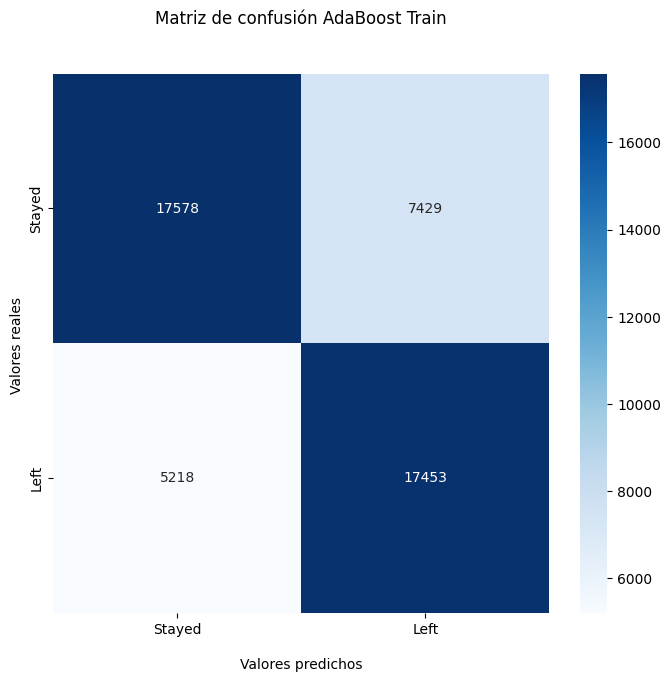

In [143]:
show_cf(matrices["AdaBoost Train"], "AdaBoost Train")

Vemos que las predicciones tienen algo mas de precisión (0.77) para el caso 'Stayed' que para el caso 'Left' (0.70).

###Test

In [144]:
print(reportes["AdaBoost Test"])

              precision    recall  f1-score   support

           0       0.77      0.70      0.73      6253
           1       0.70      0.77      0.73      5667

    accuracy                           0.73     11920
   macro avg       0.73      0.73      0.73     11920
weighted avg       0.73      0.73      0.73     11920



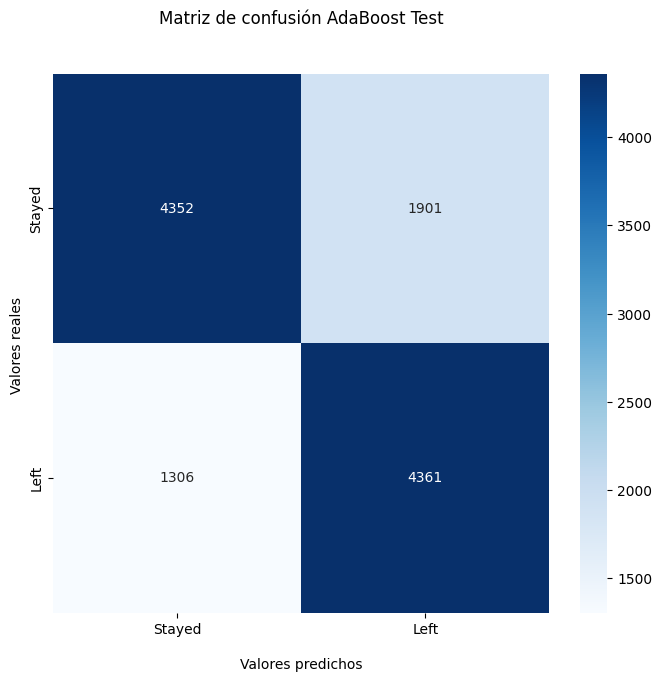

In [145]:
show_cf(matrices["AdaBoost Test"], "AdaBoost Test")

En este caso vemos un compartamiento casi igual, con predicciones un poco más acertadas para el caso 'Stayed'.

##LightGBM

Según lo calculado anteriormente hay una ligera diferencia en la precisión, siendo mayor en el caso Train.

In [146]:
print(precision["LightGBM Train"])
print(precision["LightGBM Test"])

0.7390200931247116
0.7282718120805369


###Train

In [147]:
print(reportes["LightGBM Train"])

              precision    recall  f1-score   support

           0       0.77      0.72      0.74     25007
           1       0.71      0.76      0.73     22671

    accuracy                           0.74     47678
   macro avg       0.74      0.74      0.74     47678
weighted avg       0.74      0.74      0.74     47678



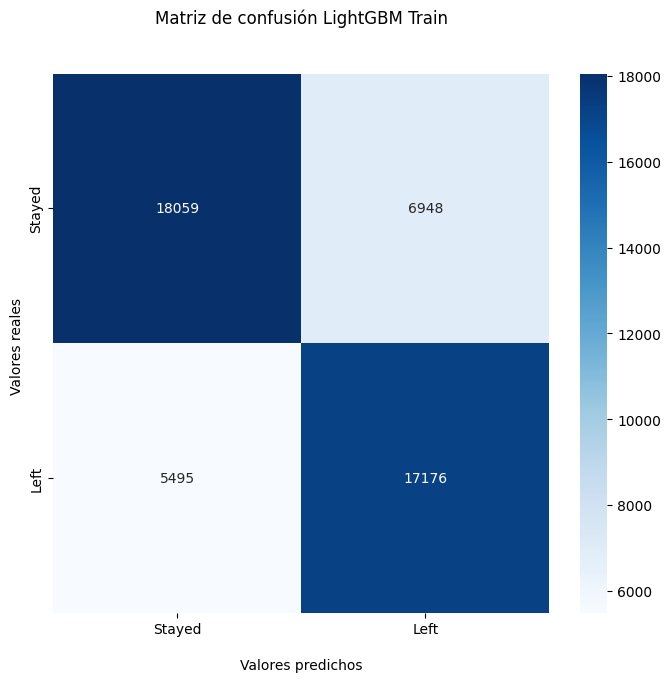

In [148]:
show_cf(matrices["LightGBM Train"], "LightGBM Train")

En este caso podemos observar una ligera mejora en cuanto a la precisión para valores 'Left' (0.71) respecto al modelo anterior.

###Test

In [149]:
print(reportes["LightGBM Test"])

              precision    recall  f1-score   support

           0       0.76      0.71      0.73      6253
           1       0.70      0.75      0.72      5667

    accuracy                           0.73     11920
   macro avg       0.73      0.73      0.73     11920
weighted avg       0.73      0.73      0.73     11920



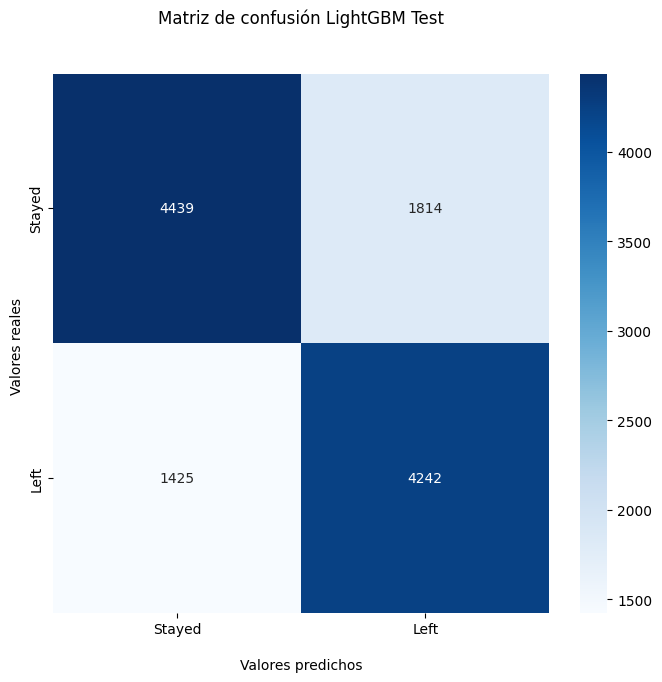

In [150]:
show_cf(matrices["LightGBM Test"], "LightGBM Test")

Vemos una reducción en la precisión tanto para 'Left' como para 'Stayed', sin ser una diferencia muy grande respecto al caso Train.

##XGBoost

Según lo calculado anteriormente tenemos 0.74 de precisión para Train y 0.72 para Test. Hasta ahora es el mejor modelo para Test que hemos evaluado.

In [151]:
print(precision["XGBoost Train"])
print(precision["XGBoost Test"])

0.7481437979781032
0.7241610738255033


###Train

In [152]:
print(reportes["XGBoost Train"])

              precision    recall  f1-score   support

           0       0.77      0.74      0.76     25007
           1       0.73      0.76      0.74     22671

    accuracy                           0.75     47678
   macro avg       0.75      0.75      0.75     47678
weighted avg       0.75      0.75      0.75     47678



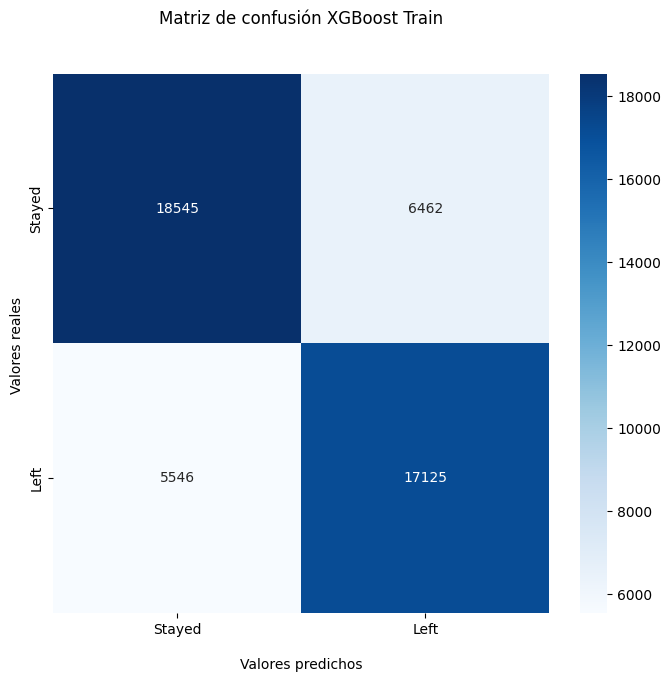

In [153]:
show_cf(matrices["XGBoost Train"], "XGBoost Train")

Con 0.77 para el caso 'Stayed' y 0.73 para el caso 'Left' hasta ahora tenemos el mejor modelo para ambos casos.

###Test

In [154]:
print(reportes["XGBoost Test"])

              precision    recall  f1-score   support

           0       0.75      0.72      0.73      6253
           1       0.70      0.73      0.72      5667

    accuracy                           0.72     11920
   macro avg       0.72      0.72      0.72     11920
weighted avg       0.73      0.72      0.72     11920



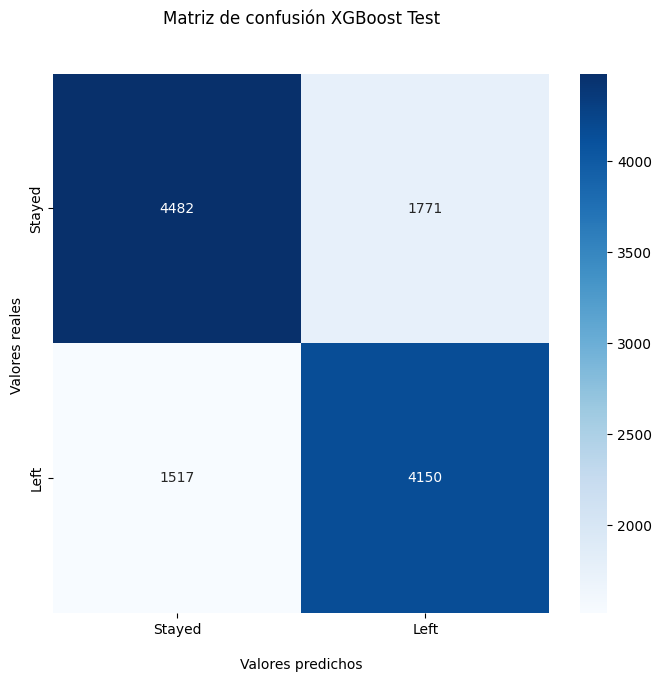

In [155]:
show_cf(matrices["XGBoost Test"], "XGBoost Test")

##KNN

###Mejora

Vamos a introducir una mejora al modelo KNN eligiendo el mejor parámetro 'n' posible. Para esto vamos a evaluar al modelo con distintos valores y nos vamos a quedar con el que nos de mayor precisión.

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29


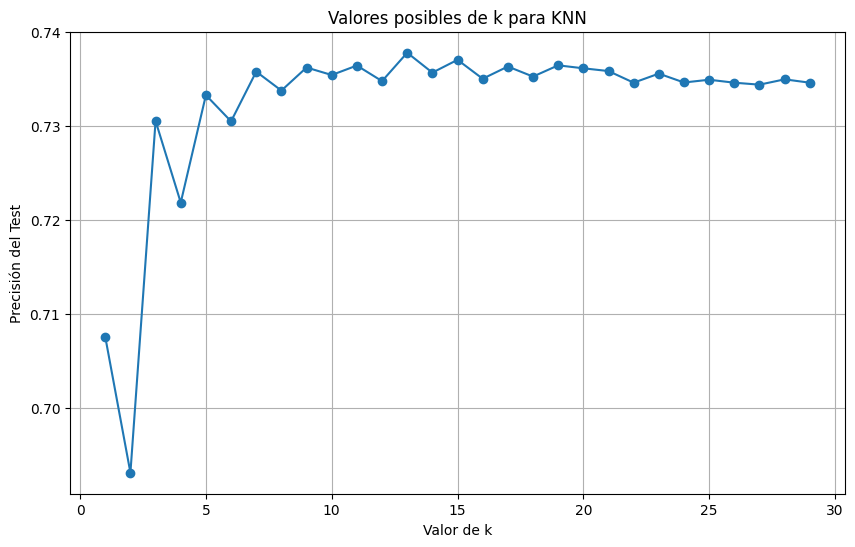

In [156]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

k_values = range(1, 30)
scores = []

for k in k_values:
    print(k)
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train_encoded)
    y_pred_knn = knn.predict(X_train_scaled)
    score = accuracy_score(y_train_encoded, y_pred_knn)
    scores.append(score)

plt.figure(figsize=(10, 6))
plt.plot(k_values, scores, marker='o')
plt.title('Valores posibles de k para KNN')
plt.xlabel('Valor de k')
plt.ylabel('Precisión del Test')
plt.grid(True)
plt.show()

Vemos que la precisión más alta se alcanza en k=13 por lo que vamos a comenzar a usar este valor

In [157]:
model = KNeighborsClassifier(n_neighbors=13)

model.fit(X_train_encoded, y_train_encoded)

y_pred_train_knn = model.predict(X_train_encoded)
y_pred_test_knn = model.predict(X_test_encoded)

accuracy_train_knn = accuracy_score(y_train_encoded, y_pred_train_knn)
accuracy_test_knn = accuracy_score(y_test_encoded, y_pred_test_knn)

precision[name + " Train"] = accuracy_train_knn
precision[name + " Test"] = accuracy_test_knn

conf_matrix_train_knn = confusion_matrix(y_train_encoded, y_pred_train_knn)
class_report_train_knn = classification_report(y_train_encoded, y_pred_train_knn)

conf_matrix_test_knn = confusion_matrix(y_test_encoded, y_pred_test_knn)
class_report_test_knn = classification_report(y_test_encoded, y_pred_test_knn)

In [158]:
print(accuracy_train_knn)
print(accuracy_test_knn)

0.735832039934561
0.7083053691275167


###Train

In [159]:
print(class_report_train_knn)

              precision    recall  f1-score   support

           0       0.75      0.75      0.75     25007
           1       0.72      0.72      0.72     22671

    accuracy                           0.74     47678
   macro avg       0.74      0.74      0.74     47678
weighted avg       0.74      0.74      0.74     47678



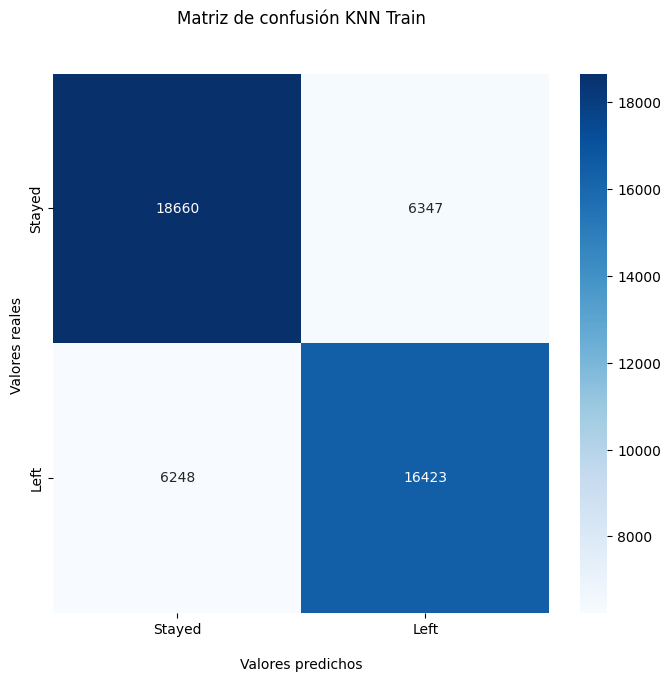

In [160]:
show_cf(conf_matrix_train_knn, "KNN Train")

###Test

In [161]:
print(class_report_test_knn)

              precision    recall  f1-score   support

           0       0.72      0.72      0.72      6253
           1       0.69      0.70      0.69      5667

    accuracy                           0.71     11920
   macro avg       0.71      0.71      0.71     11920
weighted avg       0.71      0.71      0.71     11920



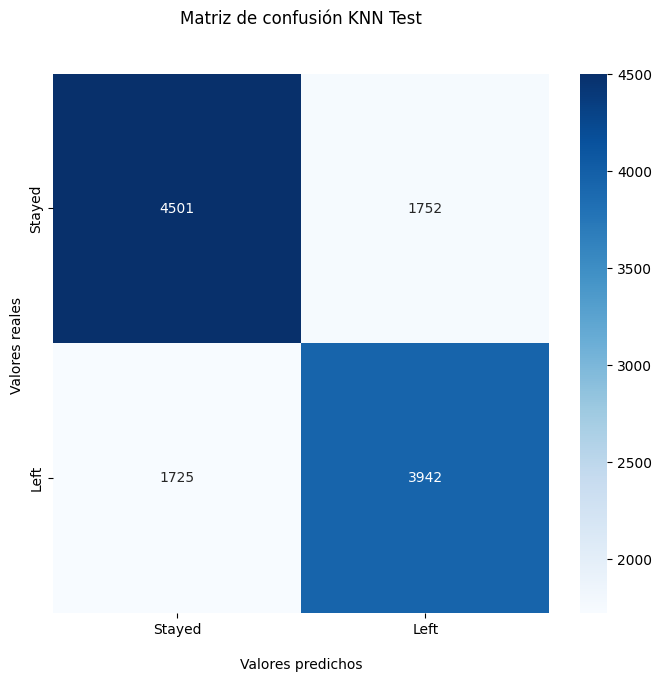

In [162]:
show_cf(conf_matrix_test_knn, "KNN Test")

En este caso vemos que hay solo un 0.69 de precisión para el caso 'Left' haciendolo hasta ahora el peor modelo para este caso.

##DecisionTree

In [163]:
print(precision["DecisionTree Train"])
print(precision["DecisionTree Test"])

0.7714249758798607
0.7057885906040269


###Train

In [164]:
print(reportes["DecisionTree Train"])

              precision    recall  f1-score   support

           0       0.78      0.79      0.78     25007
           1       0.76      0.75      0.76     22671

    accuracy                           0.77     47678
   macro avg       0.77      0.77      0.77     47678
weighted avg       0.77      0.77      0.77     47678



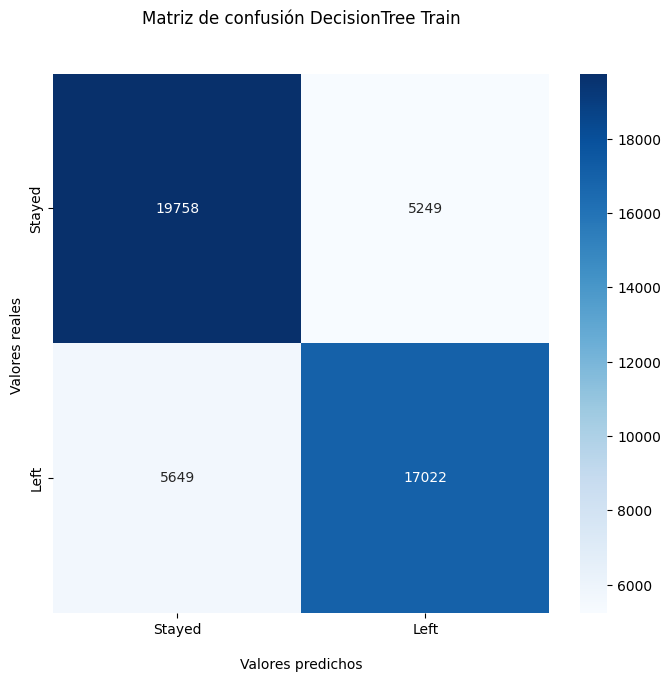

In [165]:
show_cf(matrices["DecisionTree Train"], "DecisionTree Train")

Vemos claramente que los valores de 0.78 para el caso 'Stayed' y 0.76 para el caso 'Left' son los mejores que obtuvimos hasta ahora. DecisionTree parece ser un buen modelo lo que nos lleva a pensar que RandomForest lo será también.

###Test

In [166]:
print(reportes["DecisionTree Test"])

              precision    recall  f1-score   support

           0       0.72      0.72      0.72      6253
           1       0.69      0.69      0.69      5667

    accuracy                           0.71     11920
   macro avg       0.71      0.70      0.70     11920
weighted avg       0.71      0.71      0.71     11920



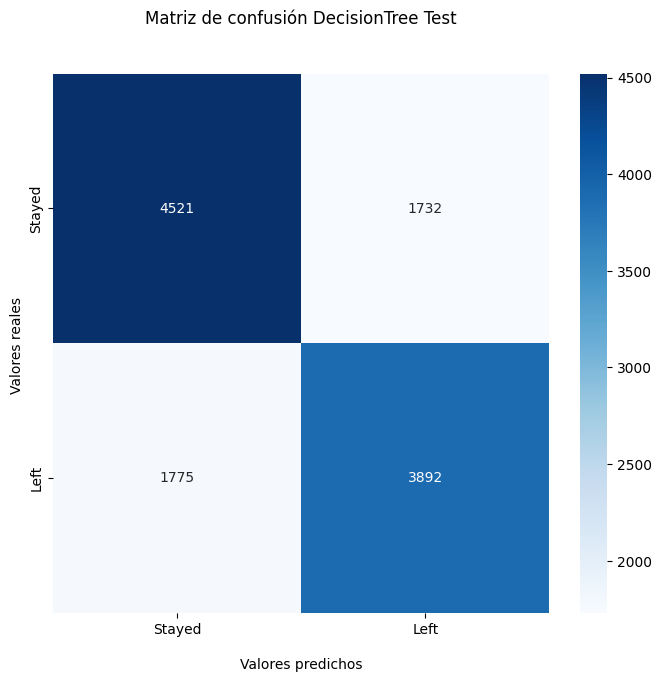

In [167]:
show_cf(matrices["DecisionTree Test"], "DecisionTree Test")

##RandomForest

In [168]:
print(precision["RandomForest Train"])
print(precision["RandomForest Test"])

0.7713410797432778
0.7093959731543624


###Train

In [169]:
print(reportes["RandomForest Train"])

              precision    recall  f1-score   support

           0       0.79      0.77      0.78     25007
           1       0.75      0.77      0.76     22671

    accuracy                           0.77     47678
   macro avg       0.77      0.77      0.77     47678
weighted avg       0.77      0.77      0.77     47678



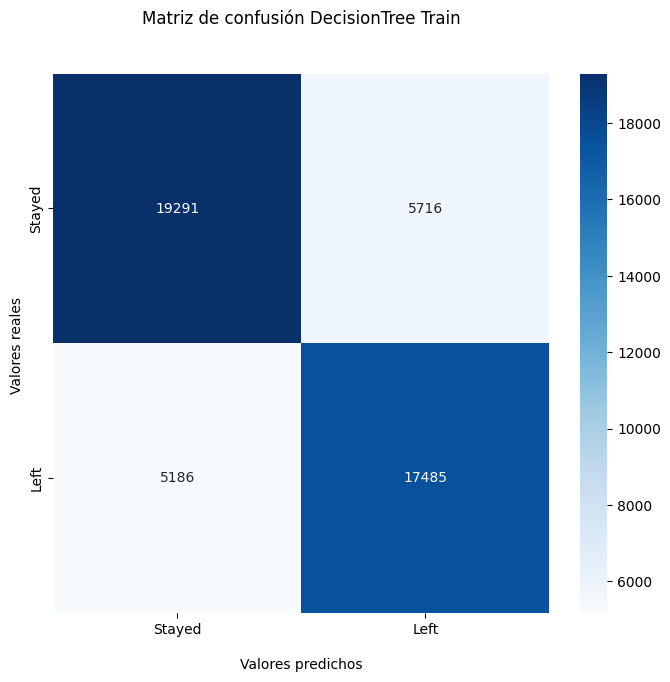

In [170]:
show_cf(matrices["RandomForest Train"], "DecisionTree Train")

Obtenemos un 0.79 de precisión para casos 'Stayed' siendo este el valor más alto que obtuvimos hasta ahora para este caso.

###Test

In [171]:
print(reportes["RandomForest Test"])

              precision    recall  f1-score   support

           0       0.73      0.71      0.72      6253
           1       0.69      0.71      0.70      5667

    accuracy                           0.71     11920
   macro avg       0.71      0.71      0.71     11920
weighted avg       0.71      0.71      0.71     11920



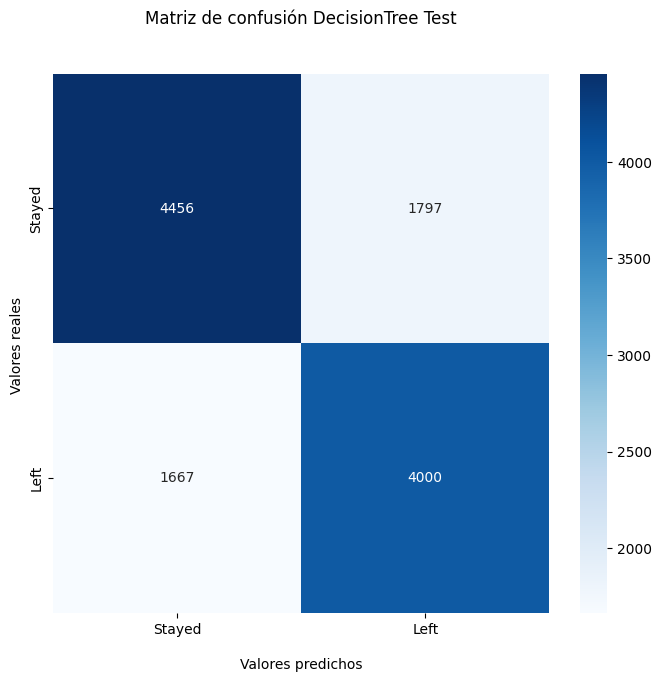

In [172]:
show_cf(matrices["RandomForest Test"], "DecisionTree Test")

##SVM

In [173]:
print(precision["SVM Train"])
print(precision["SVM Test"])

0.735832039934561
0.7083053691275167


###Train

In [174]:
print(reportes["SVM Train"])

              precision    recall  f1-score   support

           0       0.76      0.72      0.74     25007
           1       0.71      0.76      0.73     22671

    accuracy                           0.74     47678
   macro avg       0.74      0.74      0.74     47678
weighted avg       0.74      0.74      0.74     47678



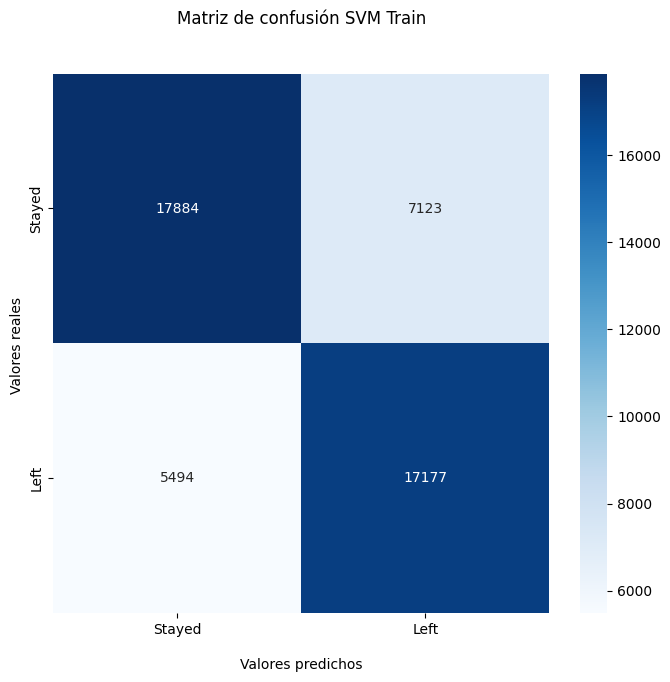

In [175]:
show_cf(matrices["SVM Train"], "SVM Train")

###Test

In [176]:
print(reportes["SVM Test"])

              precision    recall  f1-score   support

           0       0.76      0.71      0.73      6253
           1       0.70      0.75      0.72      5667

    accuracy                           0.73     11920
   macro avg       0.73      0.73      0.73     11920
weighted avg       0.73      0.73      0.73     11920



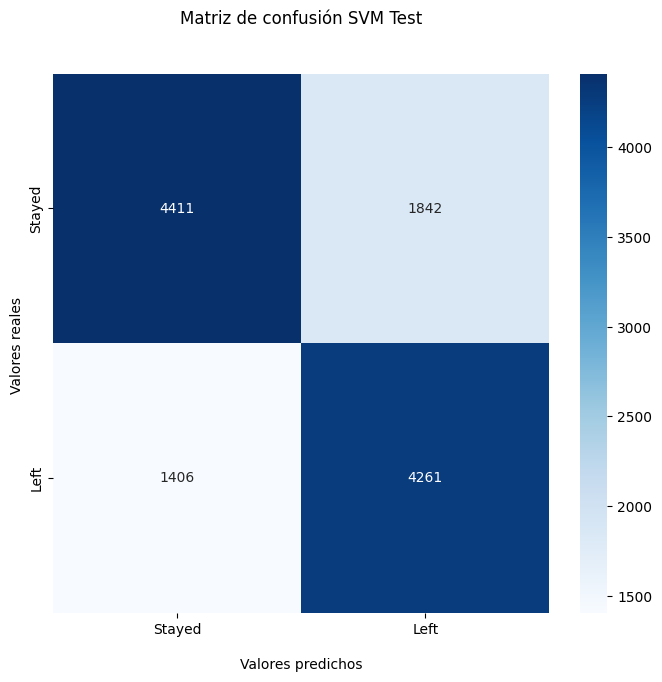

In [177]:
show_cf(matrices["SVM Test"], "SVM Test")

##Conclusiones

Luego de analizar los distintos modelos, el RandomForest resultó tener la mayor precisión para ambos casos de predicción, 'Left' y 'Stayed'.

Ninguno de los modelos mostró una gran diferencia en cuánto a precisión al comparar los conjuntos de Train y de Test. Esto es una buena señal ya que no estamos ante el problema de overfitting.

La elección del modelo óptimo no va a depender únicamente de las métricas de rendimiento generales como la exactitud, sino también de cómo estos modelos se alinean con los objetivos específicos del negocio y las expectativas del cliente.